## Configurações

In [1]:
# Extensão que verifica se um dos arquivos foi alterado
%load_ext autoreload
%autoreload 2

In [2]:
from c3_1_instance_reweighing import instance_reweighing  # É preciso começar por ele para não dar problema com o torch vindo da aif360

# Bibliotecas
import joblib
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import random
import traceback

# Variáveis auxiliares
from c0_1_configuracoes import(
  param_grid_perceptron_basico,
  param_grid_random_forest_basico,
  param_grid_regressao_logistica_basico,
  param_grid_xgboost_basico,
  param_grid_perceptron_completo,
  param_grid_random_forest_completo,
  param_grid_regressao_logistica_completo,
  param_grid_xgboost_completo,
  preprocessor_passthrough,
  seed
)

from c0_2_cronometro import cronometro

# Funções auxiliares
from c1_6_enviesamento import enviesar

# Algoritmos
from c2_1_random_forest import random_forest_GSCV
from c2_2_xgboost import xgboost_GSCV
from c2_3_regressao_logistica import regressao_logistica_GSCV
from c2_4_perceptron import perceptron_GSCV

# Técnicas de pré-processamento
from c3_1_instance_reweighing import instance_reweighing
from c3_2_disparate_impact_removal import disparate_impact_removal
from c3_3_synthetic_data_generation import synthetic_data_generation
from c3_4_suppression import suppression

# Técnicas de pós-processamento
from c4_1_threshold_optimization import threshold_optimization
from c4_2_calibration import calibration
from c4_3_reject_option_classification import reject_option_classification

# Interpretabilidade
from c5_1_interpretabilidade import gerar_interpretabilidade, gerar_interpretabilidade_especifica

# Gerar e interpretar resultados
from c6_1_salvar_resultados import gerar_planilha, salvar_dicionario

# Garantir a replicabilidade
np.random.seed(seed)
random.seed(seed)

caminho_resultado = './Resultados'

c:\Users\Gabriel\Documents\IC\venv\Lib\site-packages\inFairness\utils\ndcg.py:37: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  vect_normalized_discounted_cumulative_gain = vmap(
c:\Users\Gabriel\Documents\IC\venv\Lib\site-packages\inFairness\utils\ndcg.py:48: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  monte_carlo_vect_ndcg = vmap(

## Cálculo

In [3]:
# Chama a função que aplica todos os enviesamento considerando as variáveis sensiveis
# Não compensa salvar o arquivo pois seria muito pesado e leva apenas ~10 segundos para executar
datasets = enviesar()

In [5]:
modo_completo = 0

param_grid_random_forest = param_grid_random_forest_completo if modo_completo else param_grid_random_forest_basico
param_grid_perceptron = param_grid_perceptron_completo if modo_completo else param_grid_perceptron_basico
param_grid_regressao_logistica = param_grid_regressao_logistica_completo if modo_completo else param_grid_regressao_logistica_basico
param_grid_xgboost = param_grid_xgboost_completo if modo_completo else param_grid_xgboost_basico

algoritmos = {
    'random_forest': {
        'nome_modelo': 'RANDOM FOREST',
        'funcao': random_forest_GSCV,
        'parametros_grid': param_grid_random_forest
    },
    'perceptron': {
        'nome_modelo': 'PERCEPTRON',
        'funcao': perceptron_GSCV,
        'parametros_grid': param_grid_perceptron
    },
    'regressao_logistica': {
        'nome_modelo': 'REGRESSÃO LOGÍSTICA',
        'funcao': regressao_logistica_GSCV,
        'parametros_grid': param_grid_regressao_logistica
    },
    'xgboost': {
        'nome_modelo': 'XGBOOST',
        'funcao': xgboost_GSCV,
        'parametros_grid': param_grid_xgboost
    }
}

printar_tecnicas = False

# Parâmetros comuns para todos
parametros = {}
parametros['printar'] = True
parametros['cv_n_splits'] = 2

resultado_global = {}
sucesso = 0

# Percorre cada base de dados distinta
try:

  for df in datasets:

    print(f"\n\n=== INICIANDO ANÁLISE DO {df.upper()} ===\n")
    # Percorre cada tipo de enviesamento
    for tipo in datasets[df]:

      print(f"\n--- Analisando o tipo: {tipo} ---\n")

      banco = datasets[df][tipo]
      nome_banco = banco['nome_banco']

      # Separando dados de treino e teste
      X_train = banco['treino'].drop('target',axis=1)
      y_train = banco['treino']['target']

      X_test = banco['teste'].drop('target', axis=1)
      y_test = banco['teste']['target']

      # Passando os dados em dataframes já separados
      parametros_de_treino = parametros
      parametros_de_treino['X_train'] = X_train
      parametros_de_treino['X_test'] = X_test
      parametros_de_treino['y_train'] = y_train
      parametros_de_treino['y_test'] = y_test
      parametros_de_treino['preprocessor'] = preprocessor_passthrough # Já foram pré-processados antes
      parametros_de_treino['dados_sensiveis'] = banco['dados_sensiveis']

      resultado_dataset = {}
      resultado_dataset['smote'] = banco['smote']

      for nome_algoritmo in algoritmos:
        print(f"\n### Analisando o algoritmo: {nome_algoritmo.upper()} ###\n")

        algoritmo = algoritmos[nome_algoritmo]

        parametros_de_treino['param_grid'] = algoritmo['parametros_grid']
        parametros_de_treino['nome_modelo'] = algoritmo['nome_modelo']
        parametros_de_treino['nome_base_de_dados'] = nome_banco + f" || {algoritmo['nome_modelo']}"

        desempenho = {}

        # Pré-processamento
        with cronometro() as timer:
          desempenho['instance_reweighing']               = instance_reweighing(algoritmo['funcao'], parametros_de_treino, printar=printar_tecnicas)
        desempenho['instance_reweighing']['tempo'] = timer()

        with cronometro() as timer:
          desempenho['disparate_impact_removal']     = disparate_impact_removal(algoritmo['funcao'], parametros_de_treino, printar=printar_tecnicas)
        desempenho['disparate_impact_removal']['tempo'] = timer()

        with cronometro() as timer:
          desempenho['synthetic_data_generation']   = synthetic_data_generation(algoritmo['funcao'], parametros_de_treino, colunas_discretas=banco['colunas_discretas'], printar=printar_tecnicas)
        desempenho['synthetic_data_generation']['tempo'] = timer()

        with cronometro() as timer:  
          desempenho['suppression']                               = suppression(algoritmo['funcao'], parametros_de_treino, printar=printar_tecnicas)
        desempenho['suppression']['tempo'] = timer()

        # Pós-processamento
        with cronometro() as timer: 
          (_, desempenho['threshold_optimization'])                         = threshold_optimization(algoritmo['funcao'], parametros_de_treino, printar=printar_tecnicas)
        desempenho['threshold_optimization']['tempo'] = timer()

        with cronometro() as timer: 
          (_, desempenho['calibration'])                                               = calibration(algoritmo['funcao'], parametros_de_treino, printar=printar_tecnicas)
        desempenho['calibration']['tempo'] = timer()

        with cronometro() as timer: 
          (_, desempenho['reject_option_classification'])             = reject_option_classification(algoritmo['funcao'], parametros_de_treino, printar=printar_tecnicas)
        desempenho['reject_option_classification']['tempo'] = timer()

        # Desempenho original (sem técnica)
        parametros_de_treino['nome_base_de_dados'] = parametros_de_treino['nome_base_de_dados'] + " || SEM TÉCNICA"
        with cronometro() as timer:
          (_, desempenho['sem_tecnica']) = algoritmo['funcao'](**parametros_de_treino)
        desempenho['sem_tecnica']['tempo'] = timer()

        resultado_dataset[f"{algoritmo['nome_modelo'].lower().replace(' ', '_')}"] = desempenho

      resultado_global[f"{nome_banco.lower().replace(' ', '_')}"] = resultado_dataset.copy()

except KeyboardInterrupt:
  traceback.print_exc()


except Exception:
  traceback.print_exc()

else:
  sucesso = 1

finally:
  print("\n\n\n-------------------------------------------")
  salvar_dicionario(resultado_global, caminho_resultado, sucesso)
  gerar_planilha(resultado_global, caminho_resultado)
  print("-------------------------------------------\n\n\n")



=== INICIANDO ANÁLISE DO DF1 ===


--- Analisando o tipo: original_sensitive_sexo ---


### Analisando o algoritmo: RANDOM_FOREST ###


----- DATASET 1 ORIGINAL COM SENSITIVE SEXO || RANDOM FOREST || INSTANCE REWEIGHING || RELATÓRIO DE CLASSIFICAÇÃO -----

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      6805
           1       0.65      0.35      0.46      1958

    accuracy                           0.81      8763
   macro avg       0.74      0.65      0.67      8763
weighted avg       0.80      0.81      0.79      8763

ROC AUC: 0.7684
F1 Score: 0.4596
KS: 0.4099

----- DATASET 1 ORIGINAL COM SENSITIVE SEXO || RANDOM FOREST || INSTANCE REWEIGHING || MATRIZ DE CONFUSÃO -----

TN: 6437 | FP: 368
FN: 1264 | TP: 694

----- DATASET 1 ORIGINAL COM SENSITIVE SEXO || RANDOM FOREST || INSTANCE REWEIGHING || JUSTIÇA DO MODELO -----

----- Demographic Parity (Selection Rate) -----
Selection Rate (Desprivilegiado): 0.1129
Selection Rate (

c:\Users\Gabriel\Documents\IC\venv\Lib\site-packages\fairlearn\postprocessing\_interpolated_thresholder.py:154: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1. 1. 0. ... 0. 0. 1.]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  positive_probs[sensitive_feature_vector == a] = interpolated_predictions[



----- DATASET 1 ORIGINAL COM SENSITIVE SEXO || XGBOOST || THRESHOLD OPTIMIZATION || RELATÓRIO DE CLASSIFICAÇÃO -----

              precision    recall  f1-score   support

           0       0.84      0.94      0.89      6805
           1       0.64      0.36      0.46      1958

    accuracy                           0.81      8763
   macro avg       0.74      0.65      0.68      8763
weighted avg       0.79      0.81      0.79      8763

ROC AUC: 0.7692
F1 Score: 0.4639
KS: 0.4111

----- DATASET 1 ORIGINAL COM SENSITIVE SEXO || XGBOOST || THRESHOLD OPTIMIZATION || MATRIZ DE CONFUSÃO -----

TN: 6412 | FP: 393
FN: 1248 | TP: 710

----- DATASET 1 ORIGINAL COM SENSITIVE SEXO || XGBOOST || THRESHOLD OPTIMIZATION || JUSTIÇA DO MODELO -----

----- Demographic Parity (Selection Rate) -----
Selection Rate (Desprivilegiado): 0.1271
Selection Rate (Privilegiado):   0.1239
Demographic Parity Difference: 0.0032
Demographic Parity Ratio:    1.0255

----- True Positive Rate (Equal Opportunity) --

c:\Users\Gabriel\Documents\IC\venv\Lib\site-packages\aif360\algorithms\postprocessing\reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")



----- DATASET 1 SMOTE SIMPLES COM SENSITIVE SEXO || RANDOM FOREST || REJECT OPTION CLASSIFICATION || RELATÓRIO DE CLASSIFICAÇÃO -----

              precision    recall  f1-score   support

           0       0.84      0.93      0.88      6805
           1       0.62      0.40      0.48      1958

    accuracy                           0.81      8763
   macro avg       0.73      0.66      0.68      8763
weighted avg       0.79      0.81      0.79      8763

ROC AUC: 0.7544
F1 Score: 0.4832
KS: 0.3836

----- DATASET 1 SMOTE SIMPLES COM SENSITIVE SEXO || RANDOM FOREST || REJECT OPTION CLASSIFICATION || MATRIZ DE CONFUSÃO -----

TN: 6324 | FP: 481
FN: 1181 | TP: 777

----- DATASET 1 SMOTE SIMPLES COM SENSITIVE SEXO || RANDOM FOREST || REJECT OPTION CLASSIFICATION || JUSTIÇA DO MODELO -----

----- Demographic Parity (Selection Rate) -----
Selection Rate (Desprivilegiado): 0.1062
Selection Rate (Privilegiado):   0.2022
Demographic Parity Difference: -0.0960
Demographic Parity Ratio:    0.5

...


----- DATASET 1 SMOTE SIMPLES COM SENSITIVE SEXO || PERCEPTRON || REJECT OPTION CLASSIFICATION || RELATÓRIO DE CLASSIFICAÇÃO -----

              precision    recall  f1-score   support

           0       0.80      0.97      0.88      6805
           1       0.62      0.15      0.24      1958

    accuracy                           0.79      8763
   macro avg       0.71      0.56      0.56      8763
weighted avg       0.76      0.79      0.74      8763

ROC AUC: 0.7037
F1 Score: 0.2395
KS: 0.3192

----- DATASET 1 SMOTE SIMPLES COM SENSITIVE SEXO || PERCEPTRON || REJECT OPTION CLASSIFICATION || MATRIZ DE CONFUSÃO -----

TN: 6631 | FP: 174
FN: 1668 | TP: 290

----- DATASET 1 SMOTE SIMPLES COM SENSITIVE SEXO || PERCEPTRON || REJECT OPTION CLASSIFICATION || JUSTIÇA DO MODELO -----

----- Demographic Parity (Selection Rate) -----
Selection Rate (Desprivilegiado): 0.0271
Selection Rate (Privilegiado):   0.0935
Demographic Parity Difference: -0.0664
Demographic Parity Ratio:    0.2900

----

c:\Users\Gabriel\Documents\IC\venv\Lib\site-packages\aif360\algorithms\postprocessing\reject_option_classification.py:160: UserWarning: Unable to satisy fairness constraints
  warn("Unable to satisy fairness constraints")



----- DATASET 1 SMOTE SIMPLES COM SENSITIVE SEXO || REGRESSÃO LOGÍSTICA || REJECT OPTION CLASSIFICATION || RELATÓRIO DE CLASSIFICAÇÃO -----

              precision    recall  f1-score   support

           0       0.83      0.92      0.87      6805
           1       0.54      0.33      0.41      1958

    accuracy                           0.79      8763
   macro avg       0.69      0.62      0.64      8763
weighted avg       0.76      0.79      0.77      8763

ROC AUC: 0.6994
F1 Score: 0.4074
KS: 0.3067

----- DATASET 1 SMOTE SIMPLES COM SENSITIVE SEXO || REGRESSÃO LOGÍSTICA || REJECT OPTION CLASSIFICATION || MATRIZ DE CONFUSÃO -----

TN: 6273 | FP: 532
FN: 1321 | TP: 637

----- DATASET 1 SMOTE SIMPLES COM SENSITIVE SEXO || REGRESSÃO LOGÍSTICA || REJECT OPTION CLASSIFICATION || JUSTIÇA DO MODELO -----

----- Demographic Parity (Selection Rate) -----
Selection Rate (Desprivilegiado): 0.0490
Selection Rate (Privilegiado):   0.2657
Demographic Parity Difference: -0.2168
Demographic Pa

Traceback (most recent call last):
  File "C:\Users\Gabriel\AppData\Local\Temp\ipykernel_17224\2830676211.py", line 91, in <module>
    desempenho['disparate_impact_removal']     = disparate_impact_removal(algoritmo['funcao'], parametros_de_treino, printar=printar_tecnicas)
                                                 ~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Gabriel\Documents\IC\Codigo\c3_2_disparate_impact_removal.py", line 99, in disparate_impact_removal
    dataset_repaired_train = DIR.fit_transform(dataset_train)
  File "c:\Users\Gabriel\Documents\IC\venv\Lib\site-packages\aif360\algorithms\transformer.py", line 27, in wrapper
    new_dataset = func(self, *args, **kwargs)
  File "c:\Users\Gabriel\Documents\IC\Codigo\c3_2_disparate_impact_removal.py", line 65, in fit_transform
    return self.fit(dataset).transform(dataset)
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^
  File "c:\Users\Gabriel\Documents\IC\v




-------------------------------------------
Dicionário com o resultado parcial salvo em ./Resultados/resultado_parcial_dict_19_01_2026_18_38.joblib
Arquivo Excel com 32 linhas de dados salvo em ./Resultados/resultado_global_19_01_2026_18_38.xlsx
-------------------------------------------





## Controle manual

In [2]:
dicionario = './Resultados/resultado_global_dict_03_01_2026_19_50.joblib'

if os.path.isfile(dicionario):
  rf = joblib.load(dicionario)
  print("Dicionário recuperado")

Dicionário recuperado



PROCESSANDO: dataset_1_original_com_sensitive_age
MODELO: xgboost | TÉCNICA: threshold_optimization
Iniciando cálculo de interpretabilidade específico para: dataset_1_original_com_sensitive_age | xgboost | threshold_optimization
  > SHAP concluído em 1.09s
  > Permutation Importance concluída em 11.93s
  > LIME concluído em 87.68s


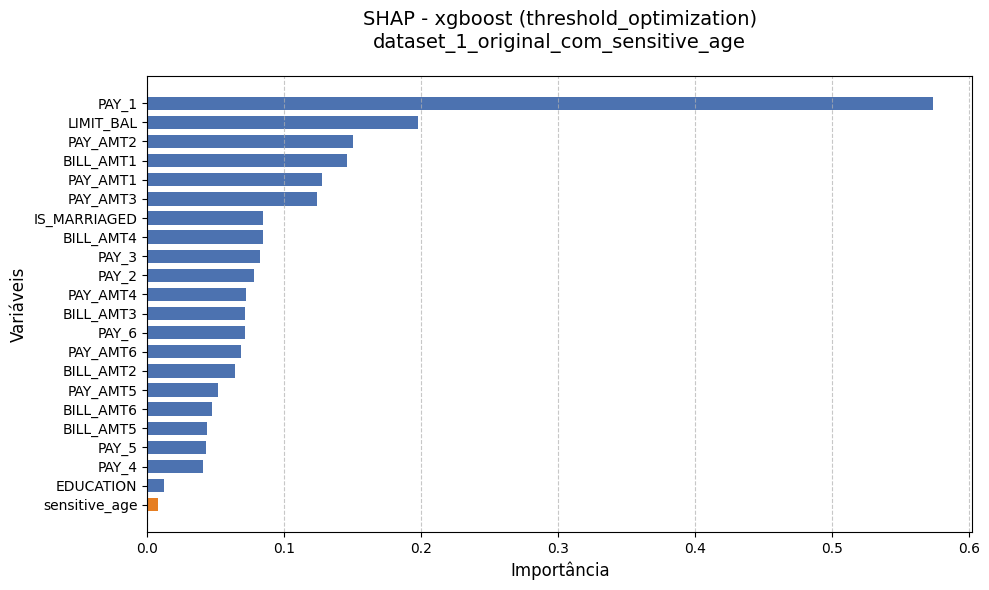

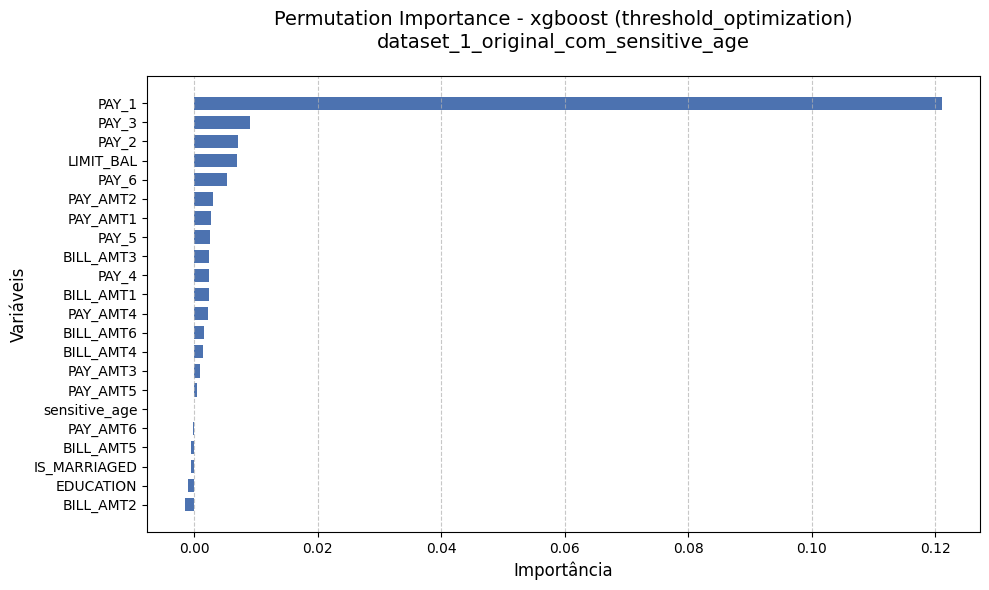

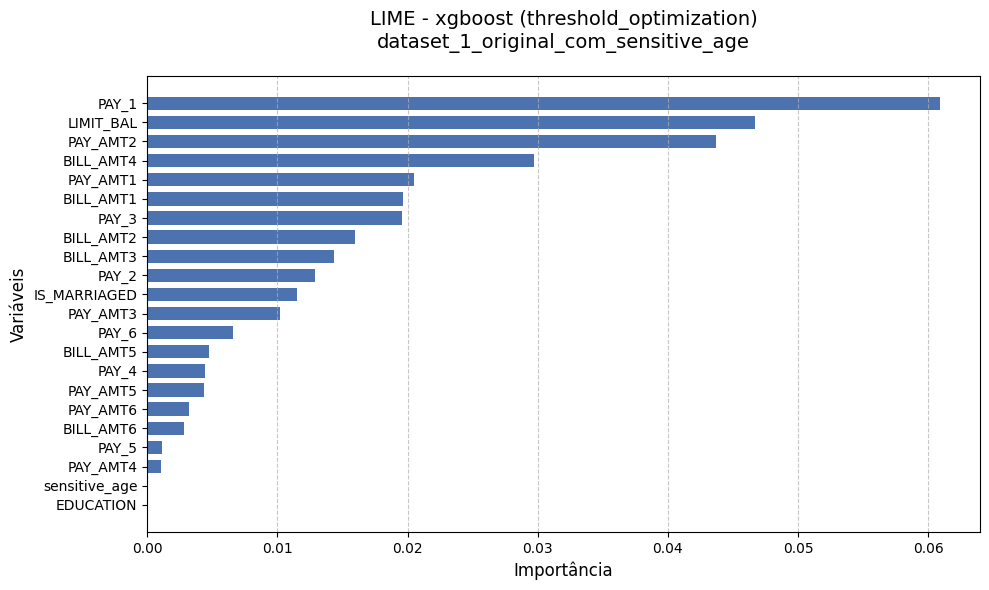


PROCESSANDO: dataset_1_original_com_sensitive_sexo
MODELO: xgboost | TÉCNICA: synthetic_data_generation
Iniciando cálculo de interpretabilidade específico para: dataset_1_original_com_sensitive_sexo | xgboost | synthetic_data_generation
  > SHAP concluído em 0.90s
  > Permutation Importance concluída em 11.15s
  > LIME concluído em 90.78s


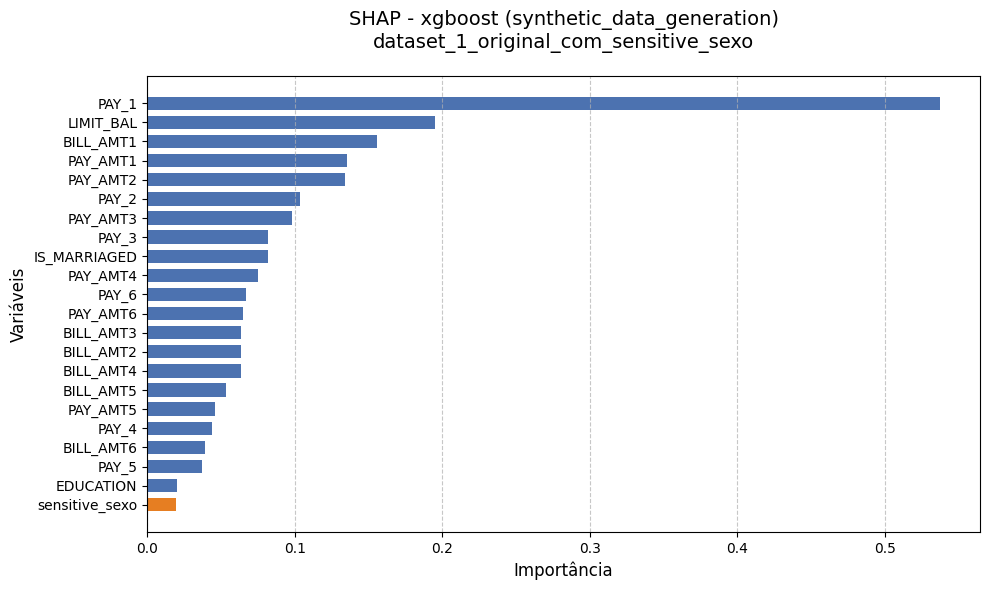

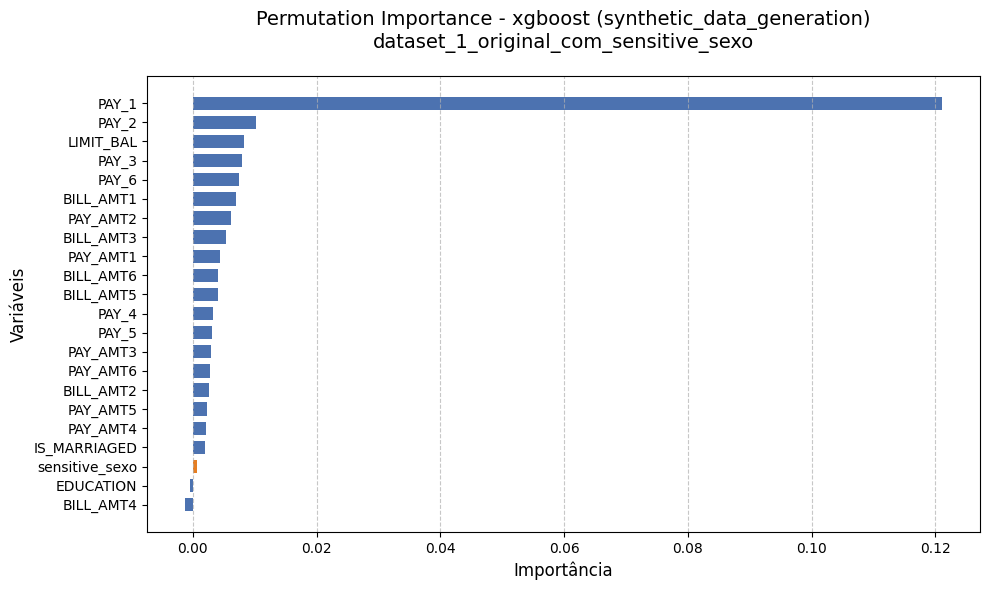

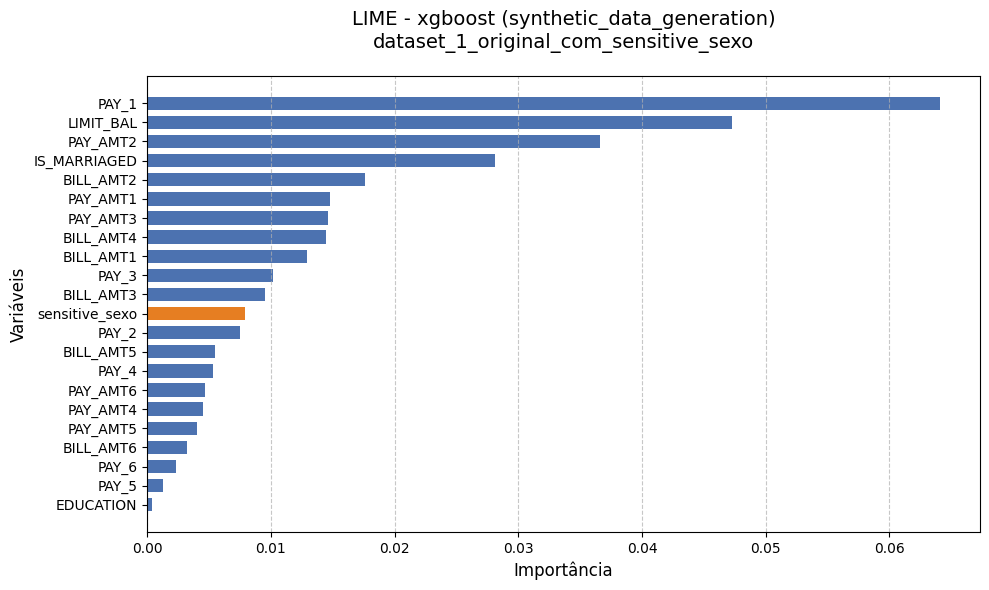


PROCESSANDO: dataset_2_original_com_sensitive_age
MODELO: regressão_logística | TÉCNICA: reject_option_classification
Iniciando cálculo de interpretabilidade específico para: dataset_2_original_com_sensitive_age | regressão_logística | reject_option_classification
  > SHAP concluído em 0.05s
  > Permutation Importance concluída em 7.28s
  > LIME concluído em 46.07s


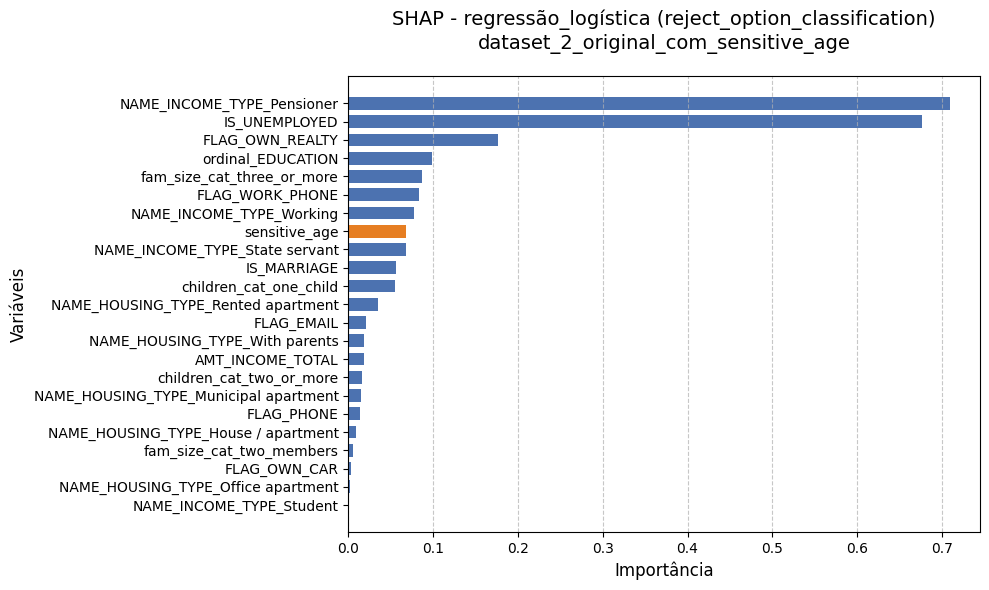

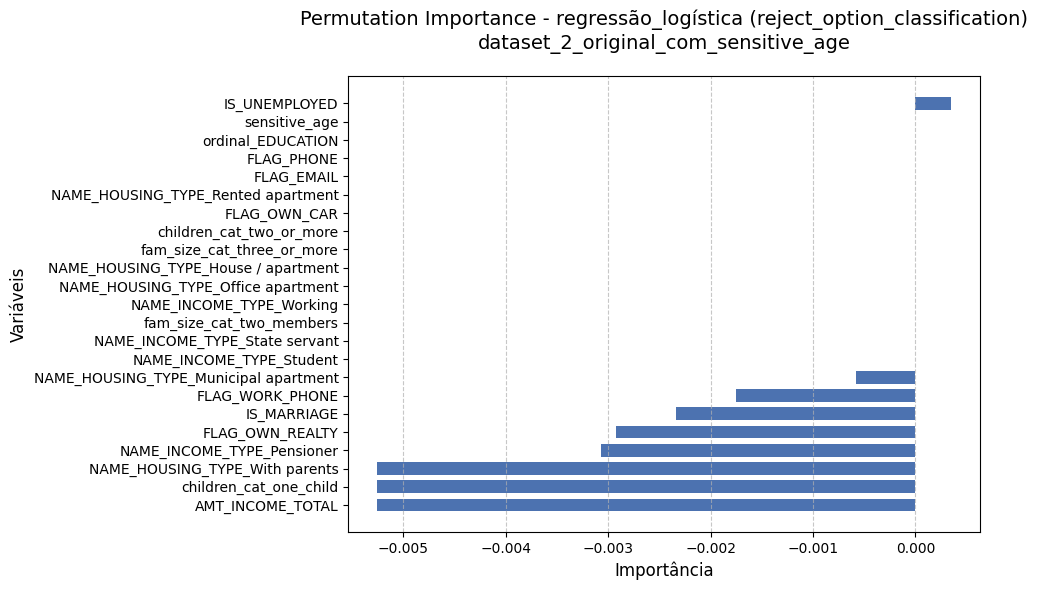

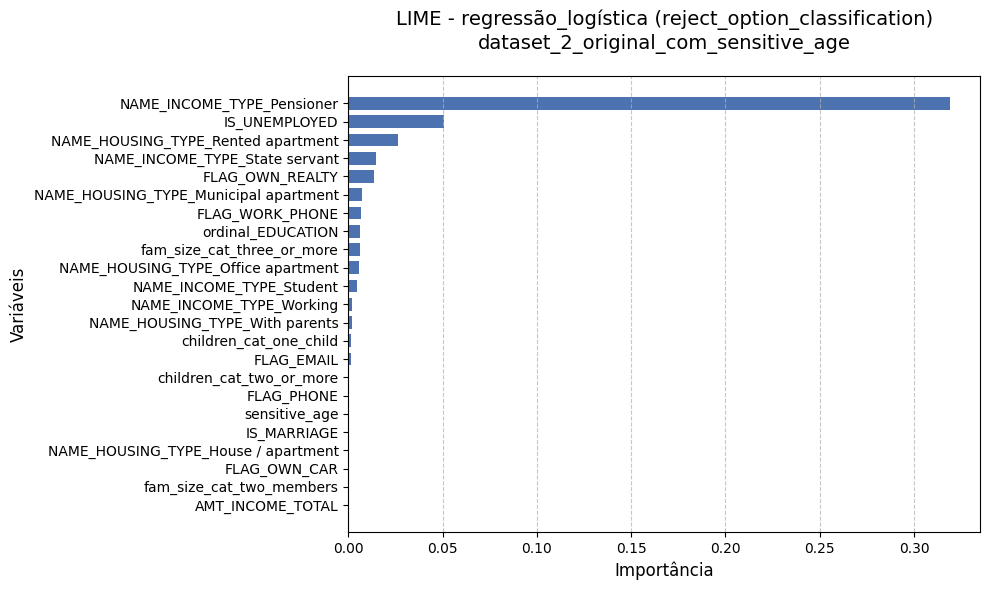


PROCESSANDO: dataset_2_original_com_sensitive_sexo
MODELO: xgboost | TÉCNICA: synthetic_data_generation
Iniciando cálculo de interpretabilidade específico para: dataset_2_original_com_sensitive_sexo | xgboost | synthetic_data_generation
  > SHAP concluído em 0.96s
  > Permutation Importance concluída em 12.29s
  > LIME concluído em 42.66s


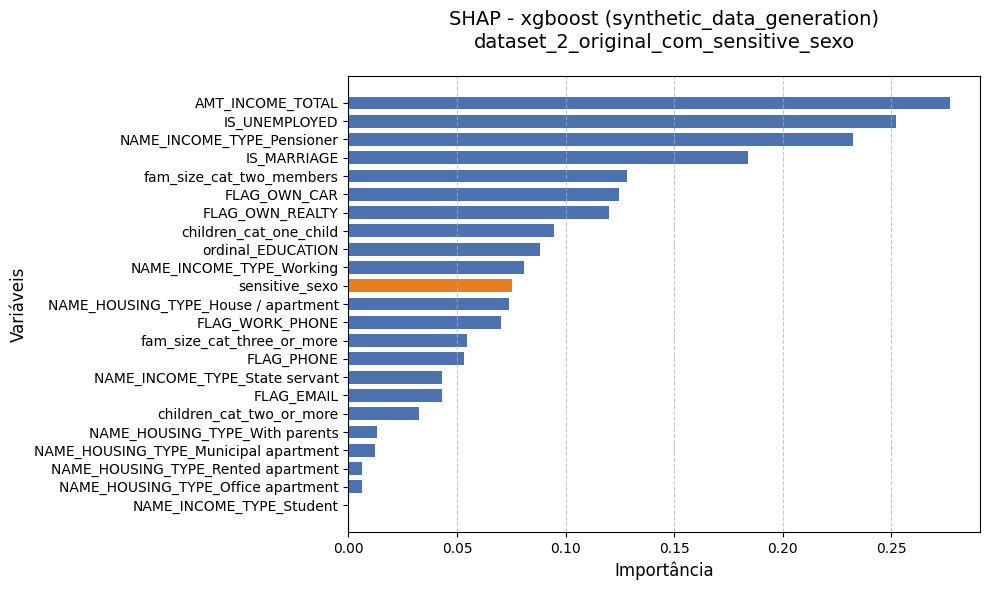

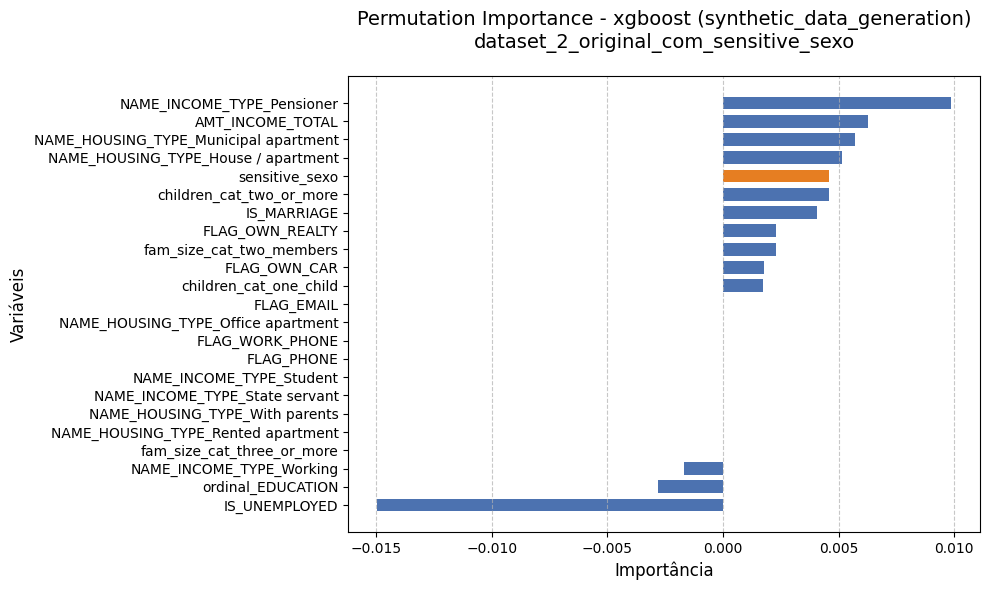

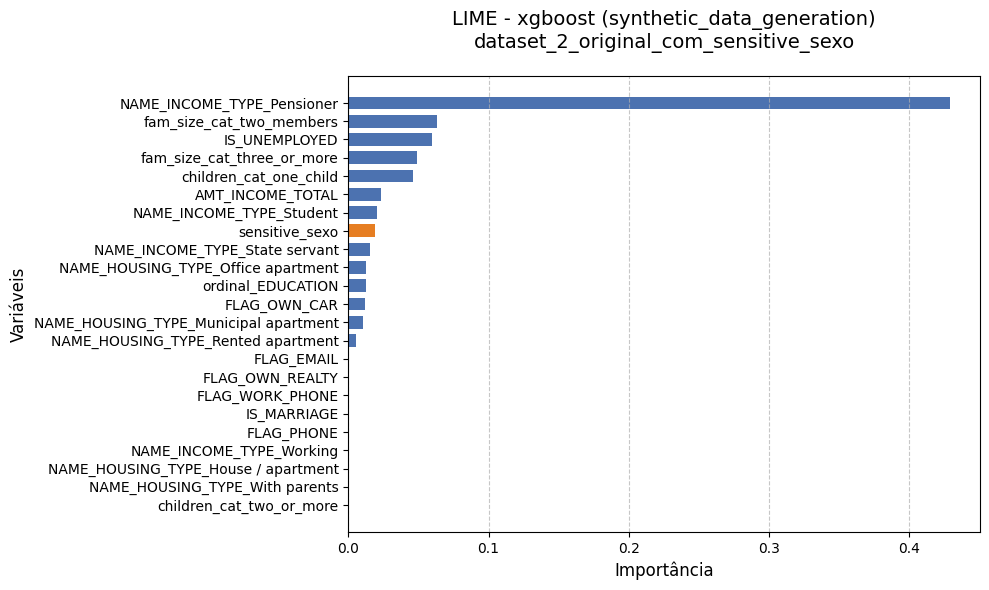


PROCESSANDO: dataset_3_original_com_sensitive_age
MODELO: random_forest | TÉCNICA: calibration
Iniciando cálculo de interpretabilidade específico para: dataset_3_original_com_sensitive_age | random_forest | calibration
  > SHAP concluído em 13.39s
  > Permutation Importance concluída em 19.34s
  > LIME concluído em 74.06s


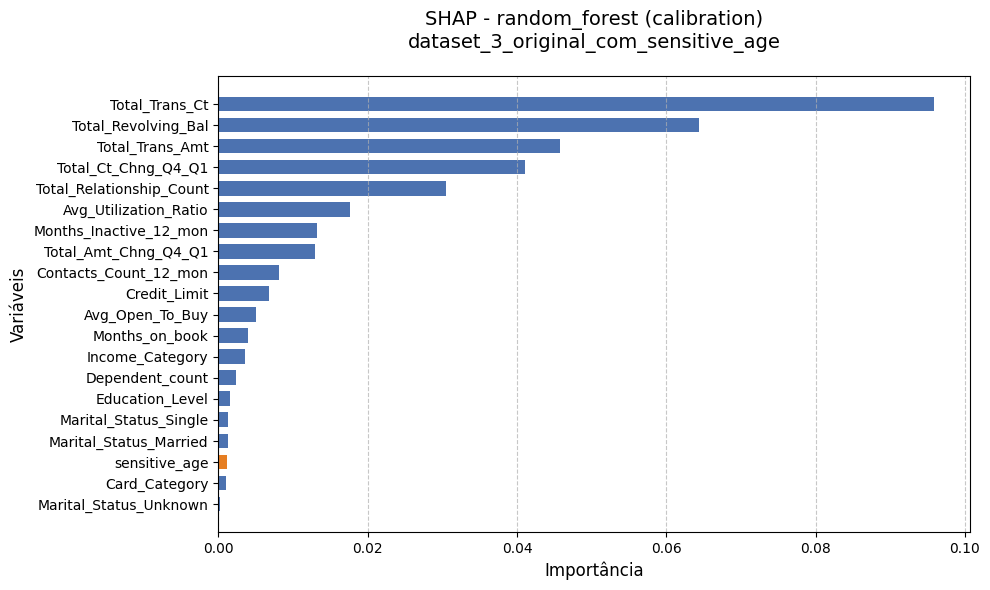

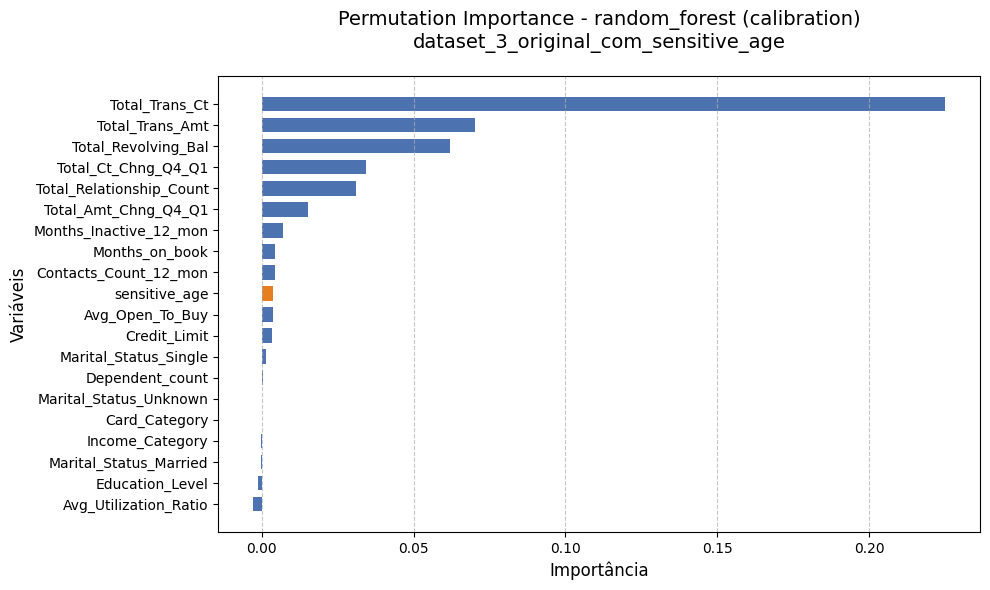

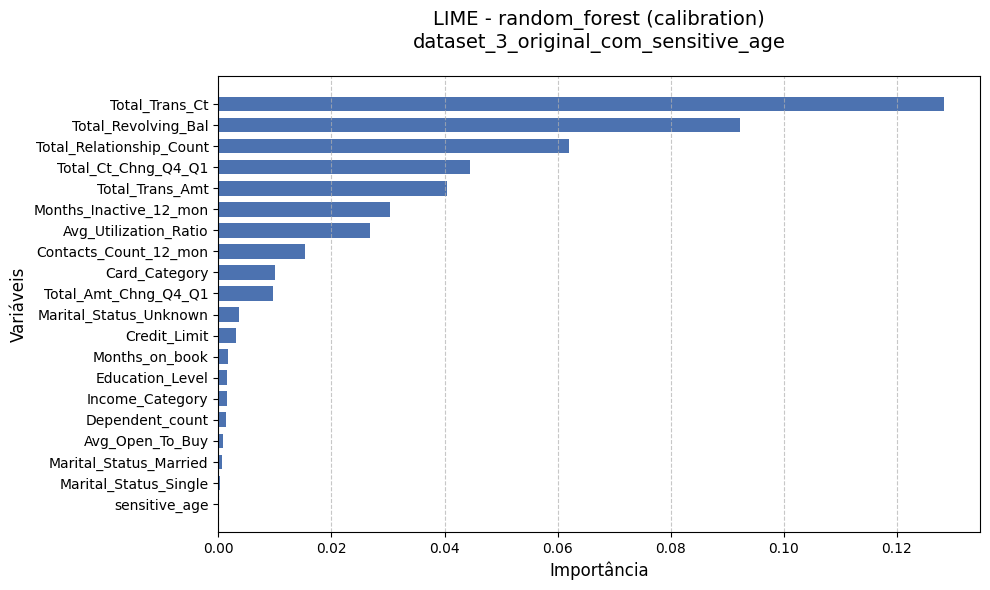


PROCESSANDO: dataset_3_original_com_sensitive_sexo
MODELO: xgboost | TÉCNICA: sem_tecnica
Iniciando cálculo de interpretabilidade específico para: dataset_3_original_com_sensitive_sexo | xgboost | sem_tecnica
  > SHAP concluído em 0.36s
  > Permutation Importance concluída em 2.10s
  > LIME concluído em 58.24s


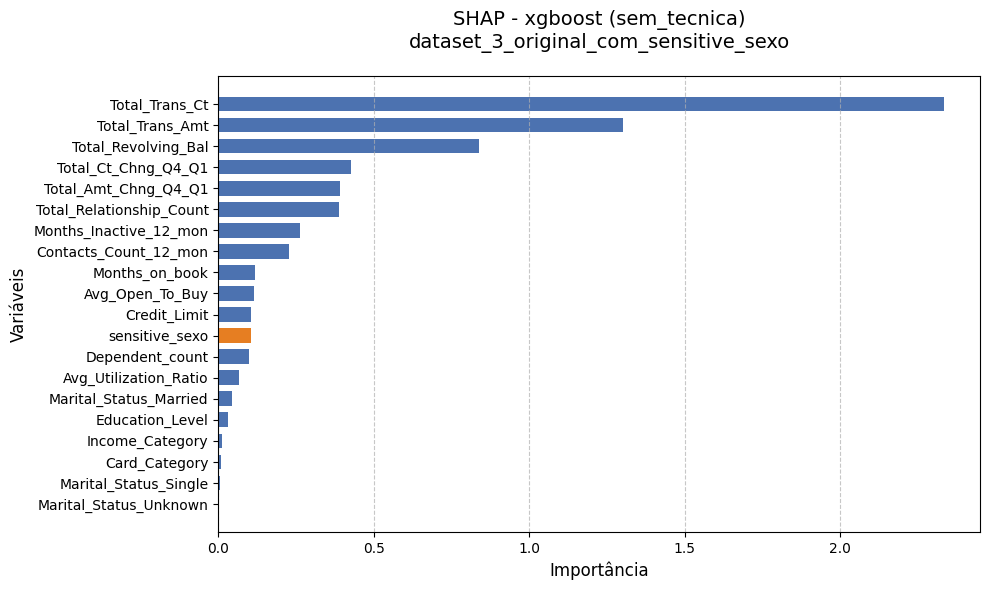

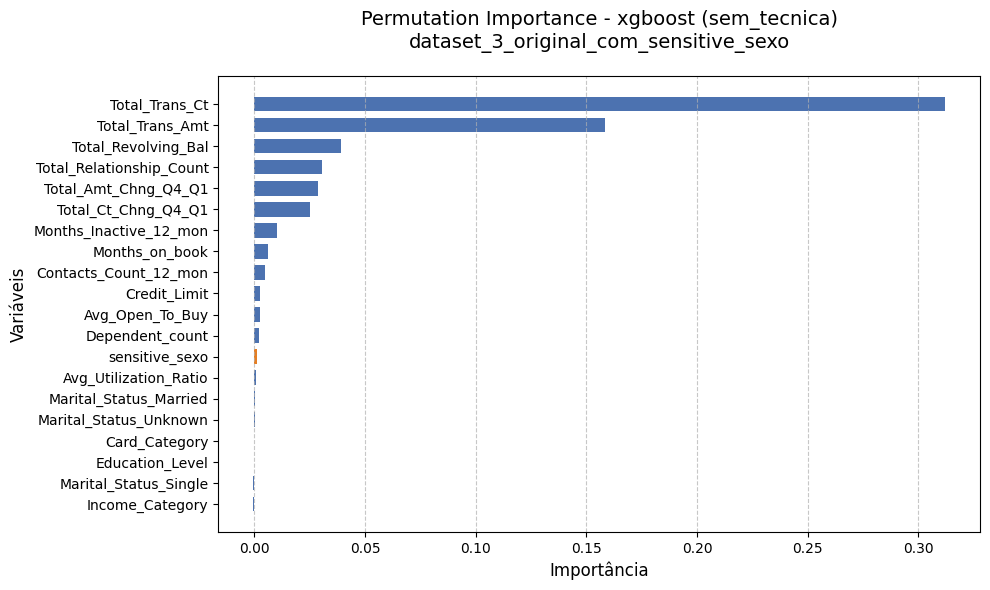

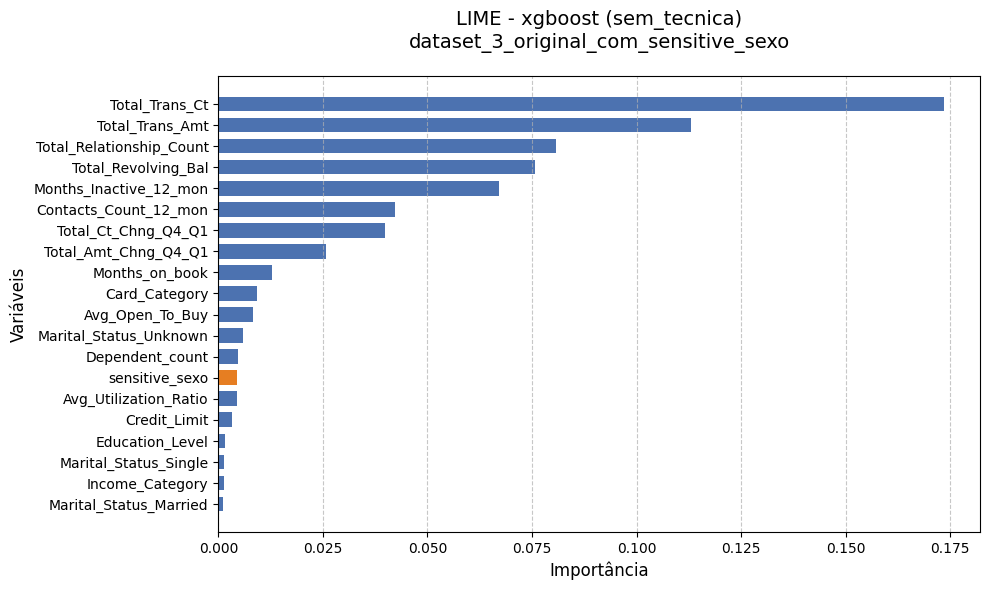


PROCESSANDO: dataset_4_original_com_sensitive_age
MODELO: xgboost | TÉCNICA: sem_tecnica
Iniciando cálculo de interpretabilidade específico para: dataset_4_original_com_sensitive_age | xgboost | sem_tecnica
  > SHAP concluído em 0.15s
  > Permutation Importance concluída em 4.33s
  > LIME concluído em 78.61s


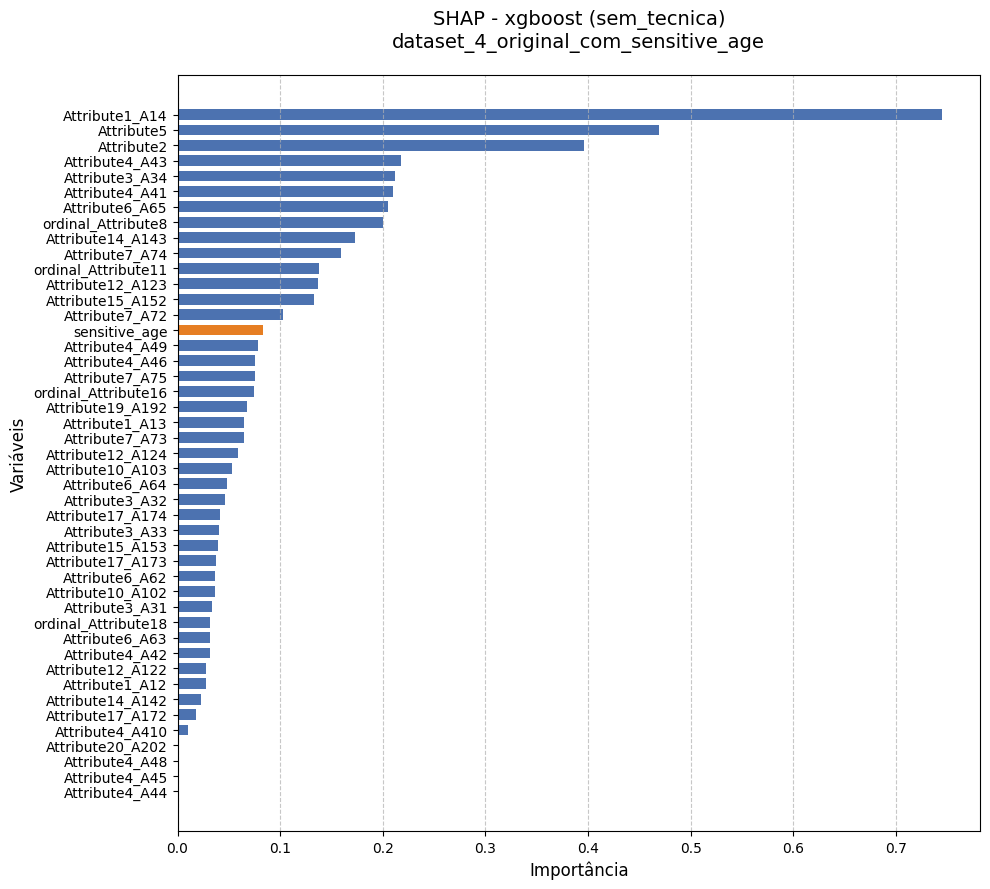

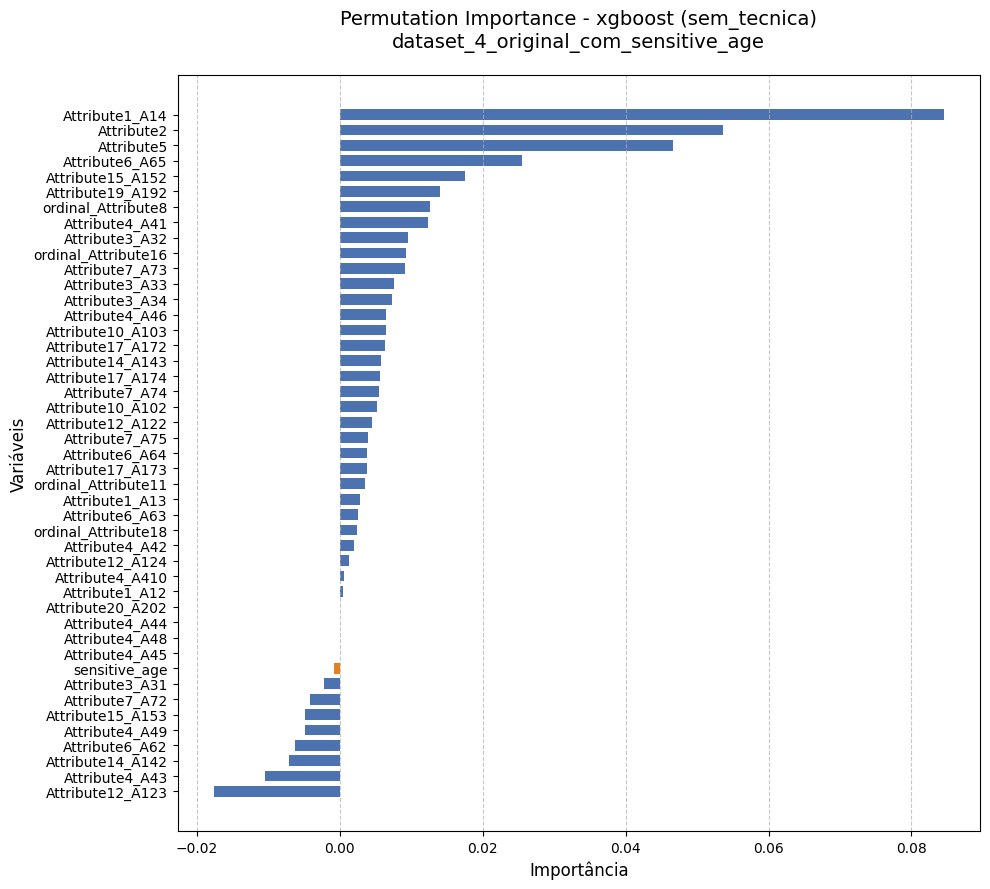

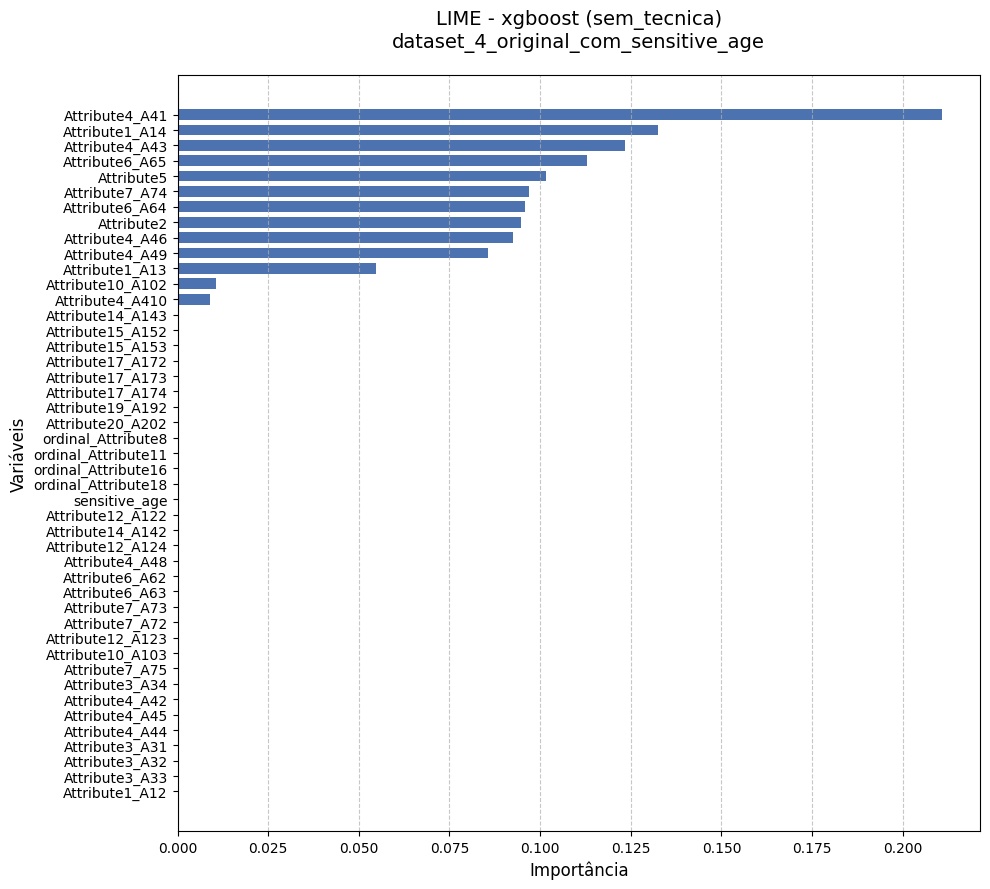


PROCESSANDO: dataset_4_original_com_sensitive_sexo
MODELO: xgboost | TÉCNICA: sem_tecnica
Iniciando cálculo de interpretabilidade específico para: dataset_4_original_com_sensitive_sexo | xgboost | sem_tecnica
  > SHAP concluído em 0.17s
  > Permutation Importance concluída em 4.18s
  > LIME concluído em 76.65s


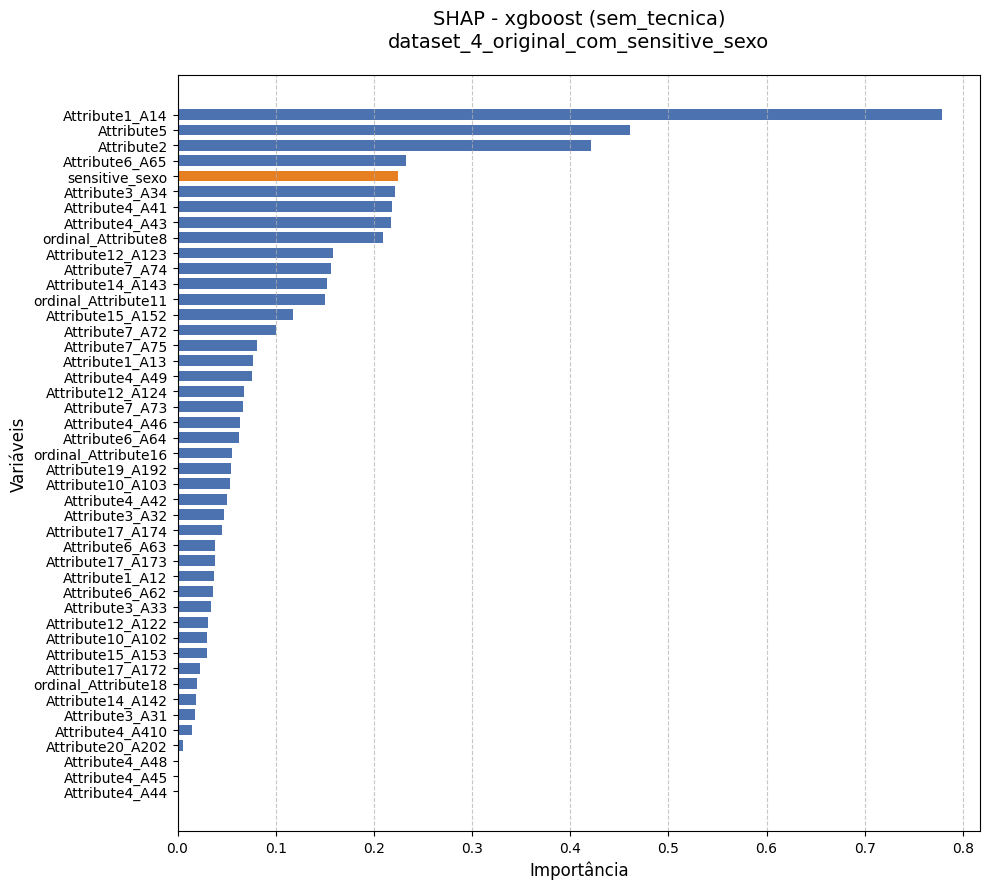

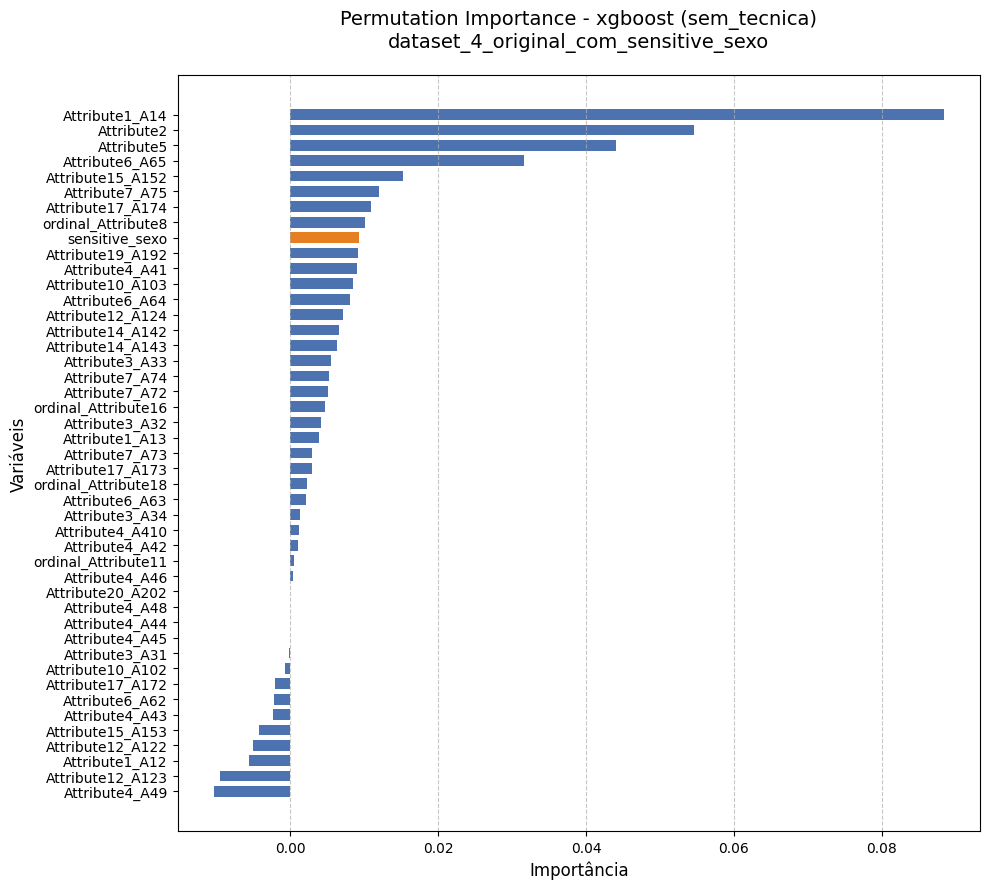

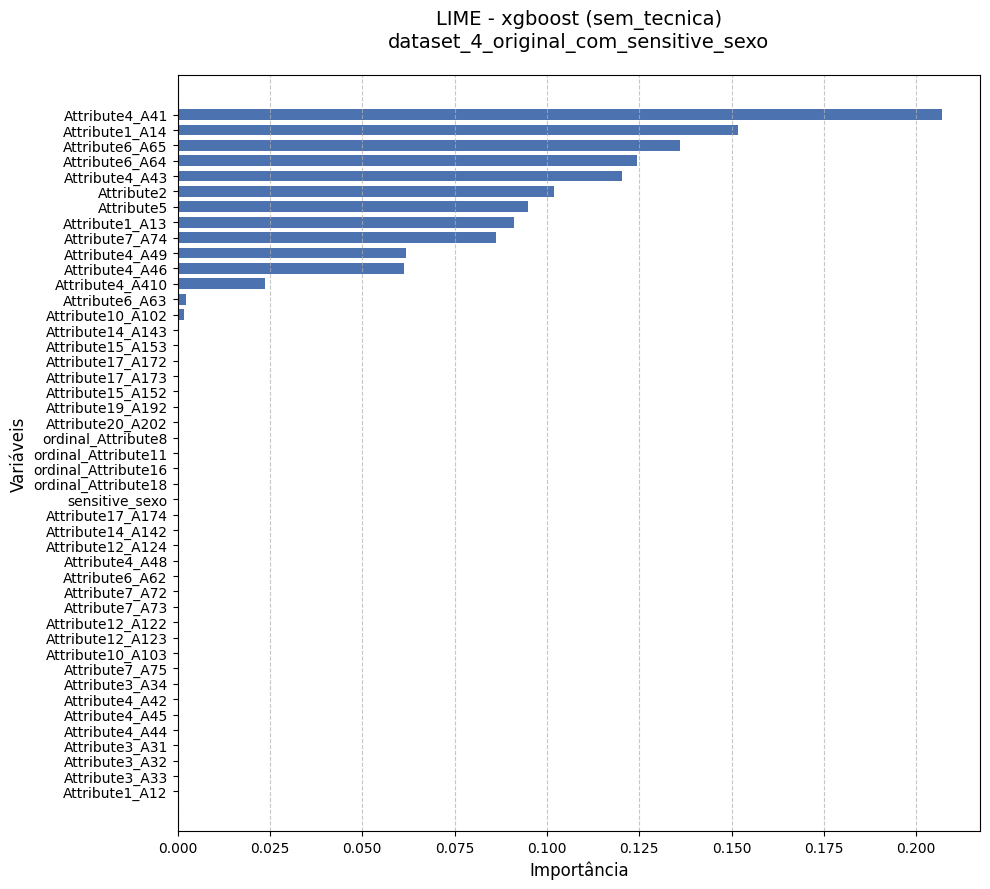


PROCESSANDO: dataset_1_smote_simples_com_sensitive_age
MODELO: random_forest | TÉCNICA: suppression
Iniciando cálculo de interpretabilidade específico para: dataset_1_smote_simples_com_sensitive_age | random_forest | suppression
  > SHAP concluído em 127.93s
  > Permutation Importance concluída em 80.23s
  > LIME concluído em 103.77s


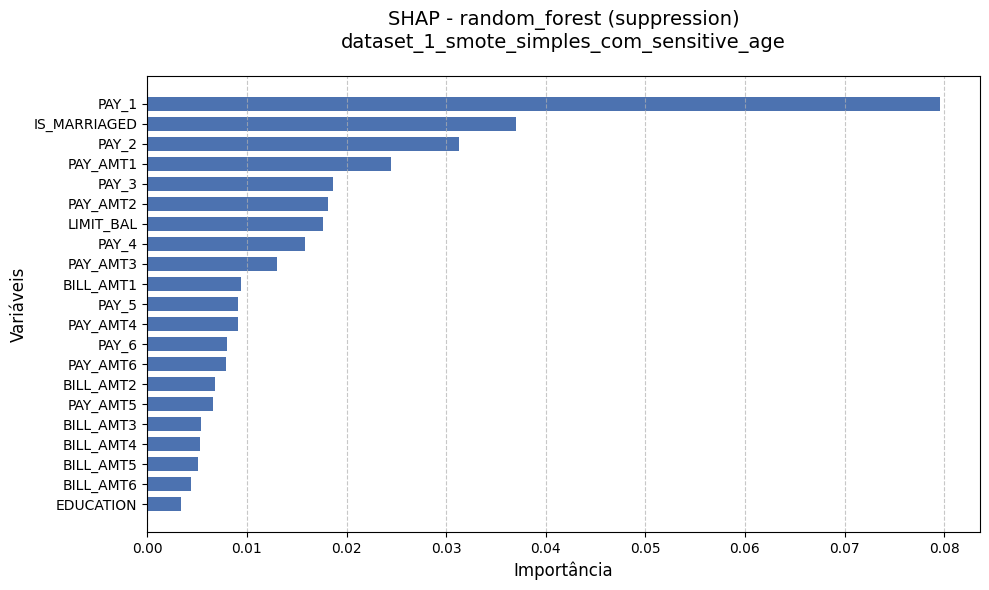

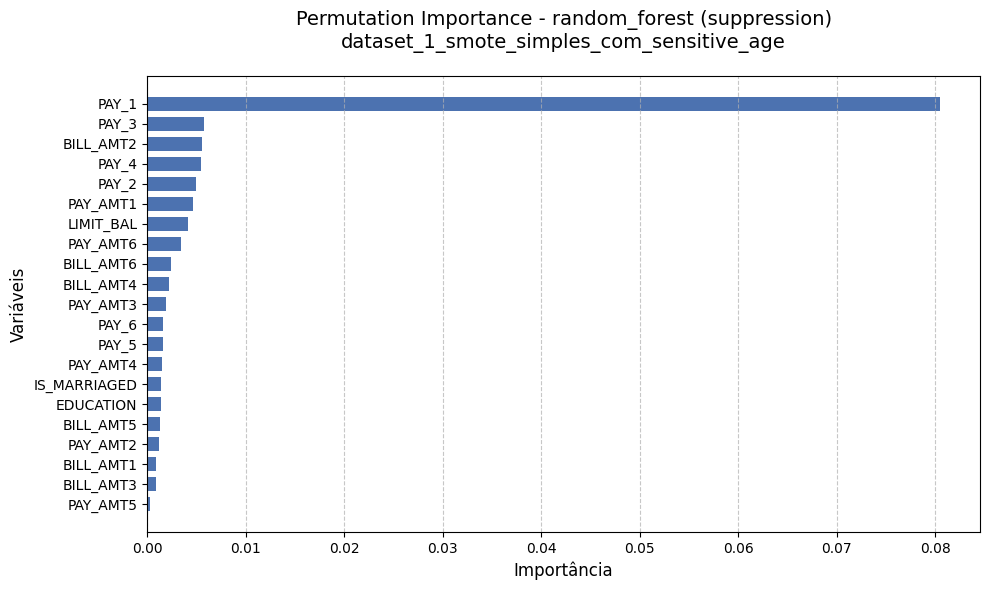

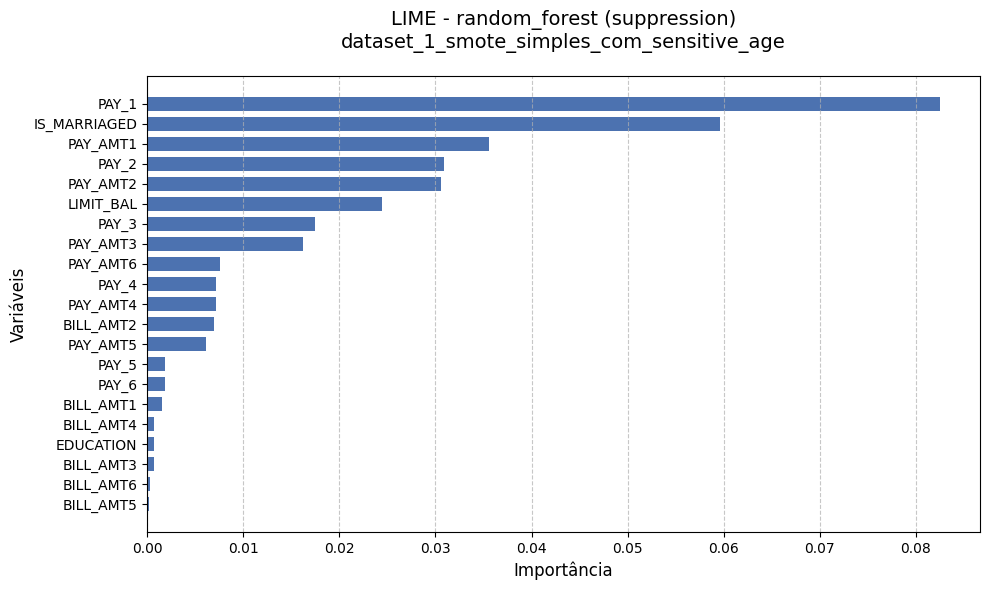


PROCESSANDO: dataset_1_smote_simples_com_sensitive_sexo
MODELO: random_forest | TÉCNICA: synthetic_data_generation
Iniciando cálculo de interpretabilidade específico para: dataset_1_smote_simples_com_sensitive_sexo | random_forest | synthetic_data_generation
  > SHAP concluído em 132.53s
  > Permutation Importance concluída em 74.31s
  > LIME concluído em 91.90s


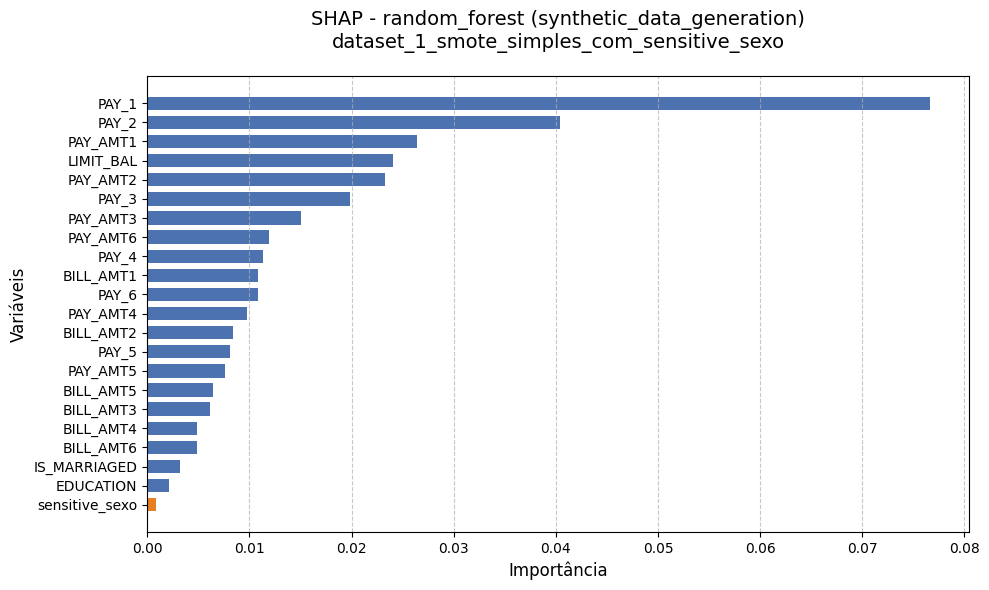

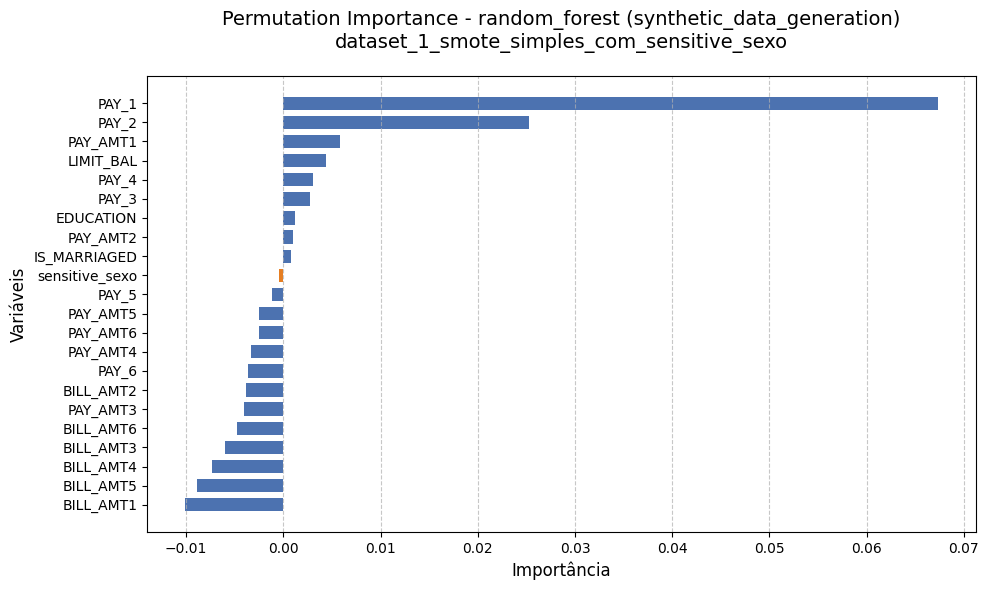

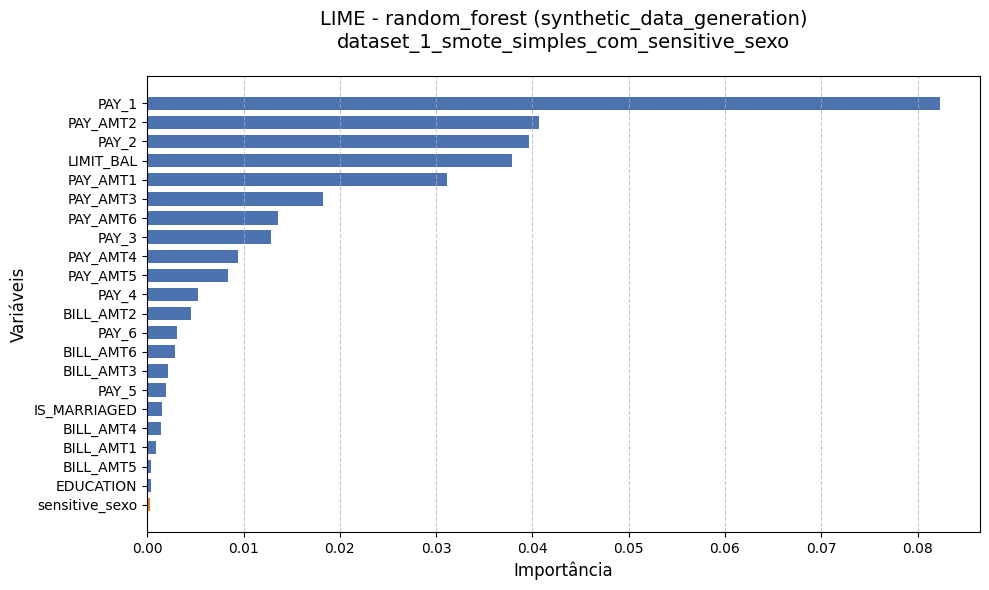


PROCESSANDO: dataset_2_smote_simples_com_sensitive_age
MODELO: xgboost | TÉCNICA: instance_reweighing
Iniciando cálculo de interpretabilidade específico para: dataset_2_smote_simples_com_sensitive_age | xgboost | instance_reweighing
  > SHAP concluído em 0.77s
  > Permutation Importance concluída em 10.83s
  > LIME concluído em 47.30s


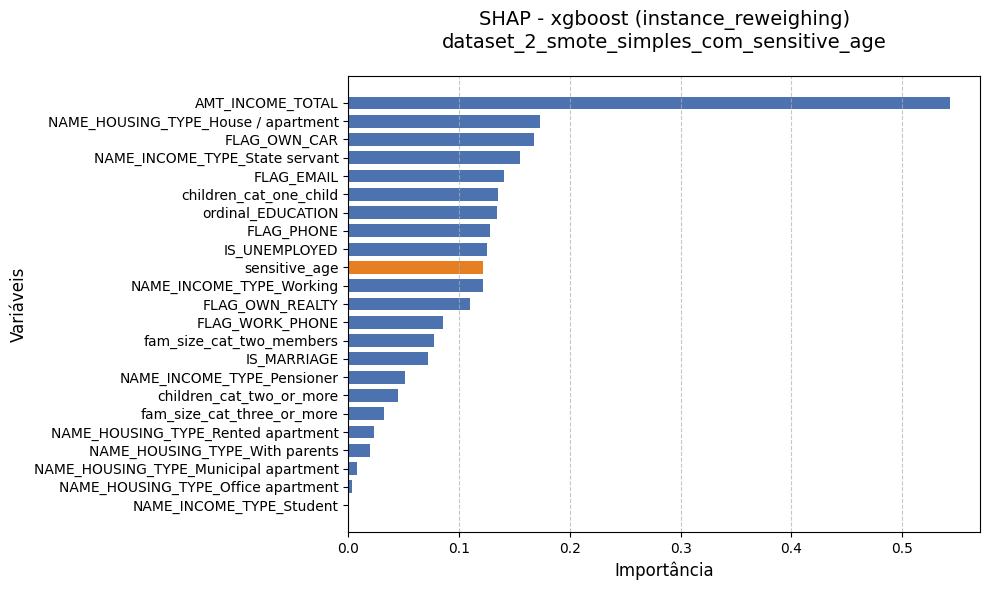

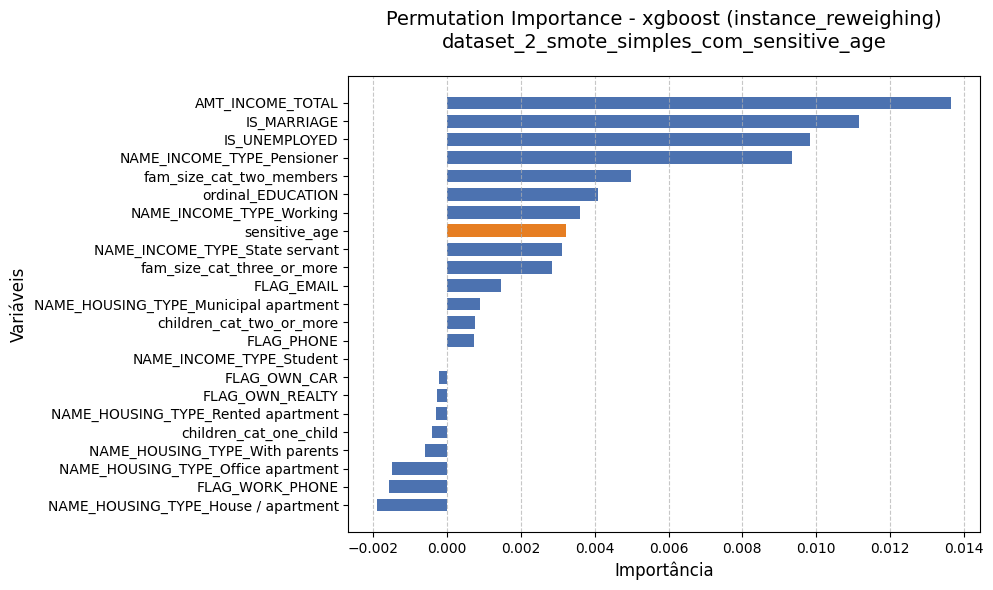

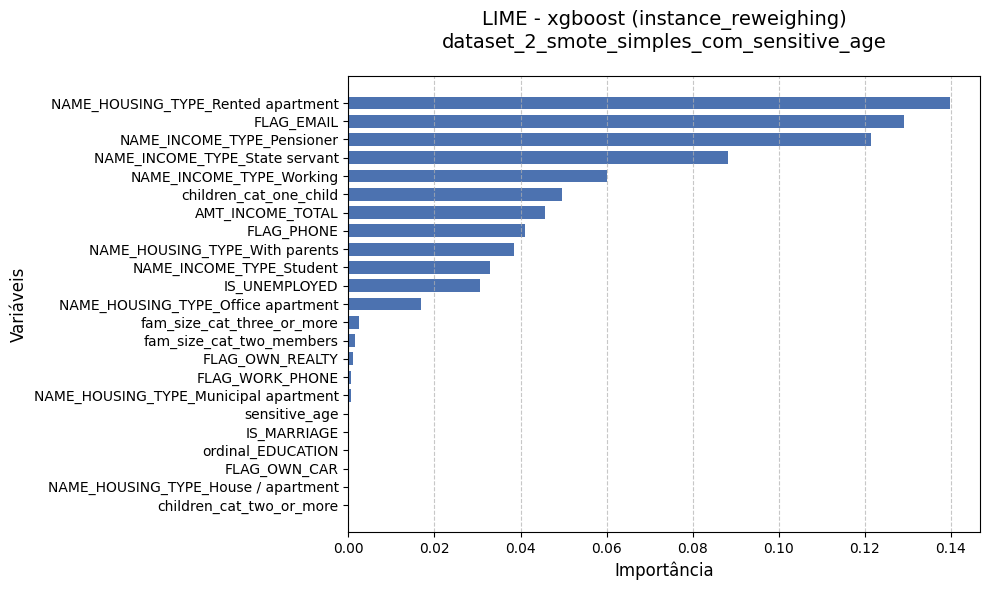


PROCESSANDO: dataset_2_smote_simples_com_sensitive_sexo
MODELO: xgboost | TÉCNICA: instance_reweighing
Iniciando cálculo de interpretabilidade específico para: dataset_2_smote_simples_com_sensitive_sexo | xgboost | instance_reweighing
  > SHAP concluído em 0.91s
  > Permutation Importance concluída em 11.98s
  > LIME concluído em 44.86s


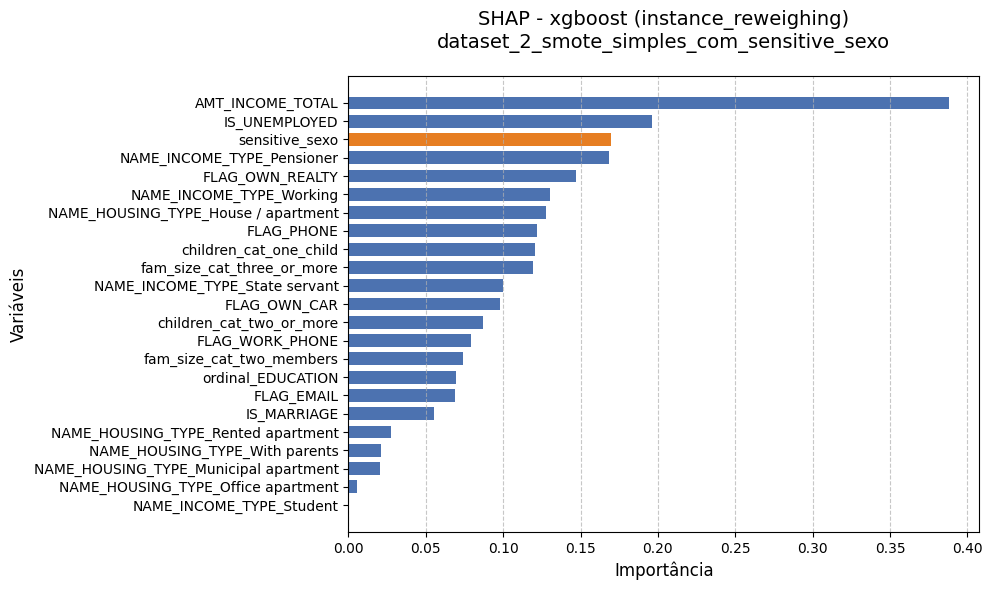

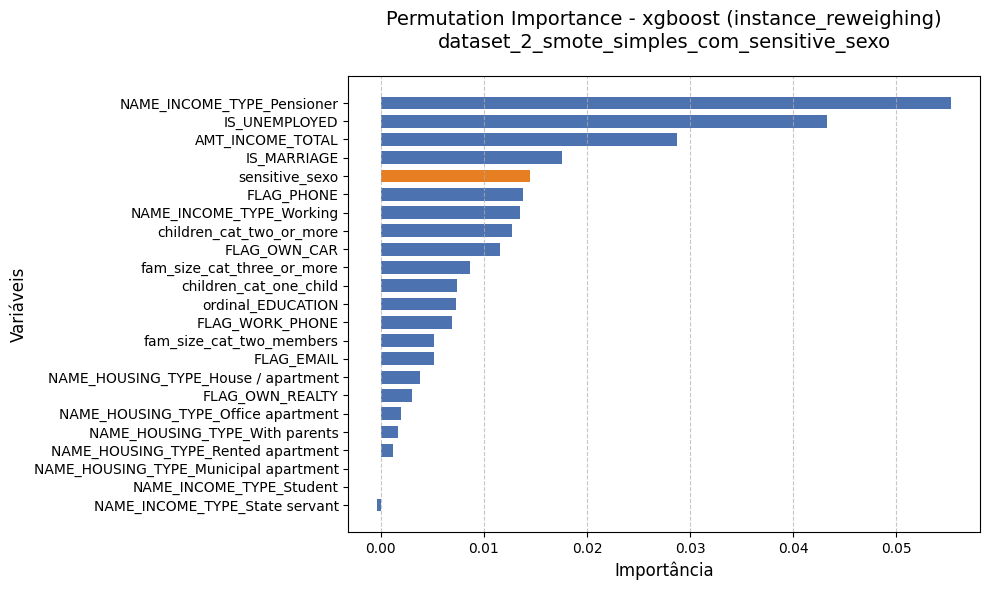

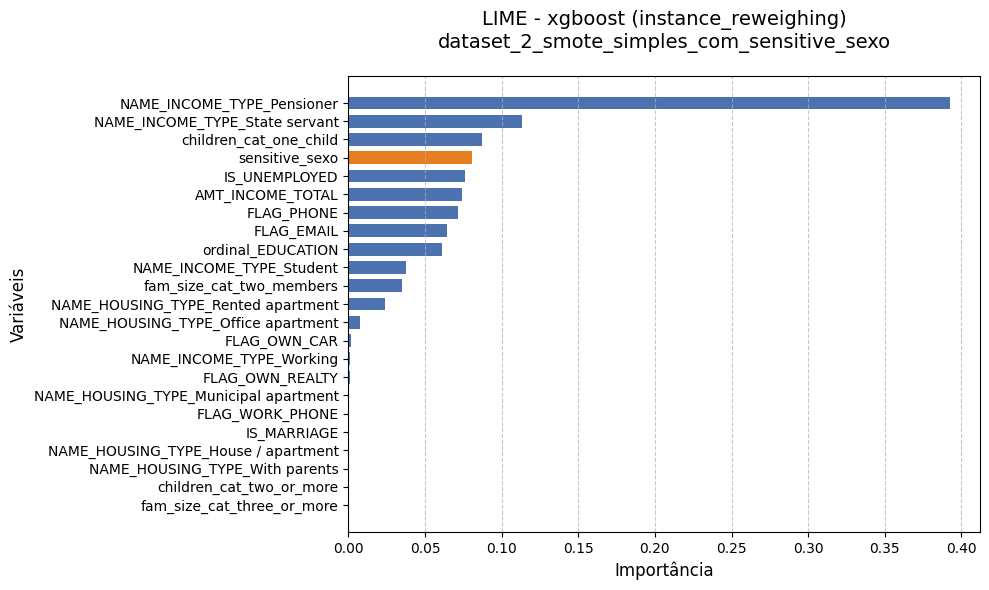


PROCESSANDO: dataset_3_smote_simples_com_sensitive_age
MODELO: xgboost | TÉCNICA: suppression
Iniciando cálculo de interpretabilidade específico para: dataset_3_smote_simples_com_sensitive_age | xgboost | suppression
  > SHAP concluído em 0.43s
  > Permutation Importance concluída em 2.32s
  > LIME concluído em 56.63s


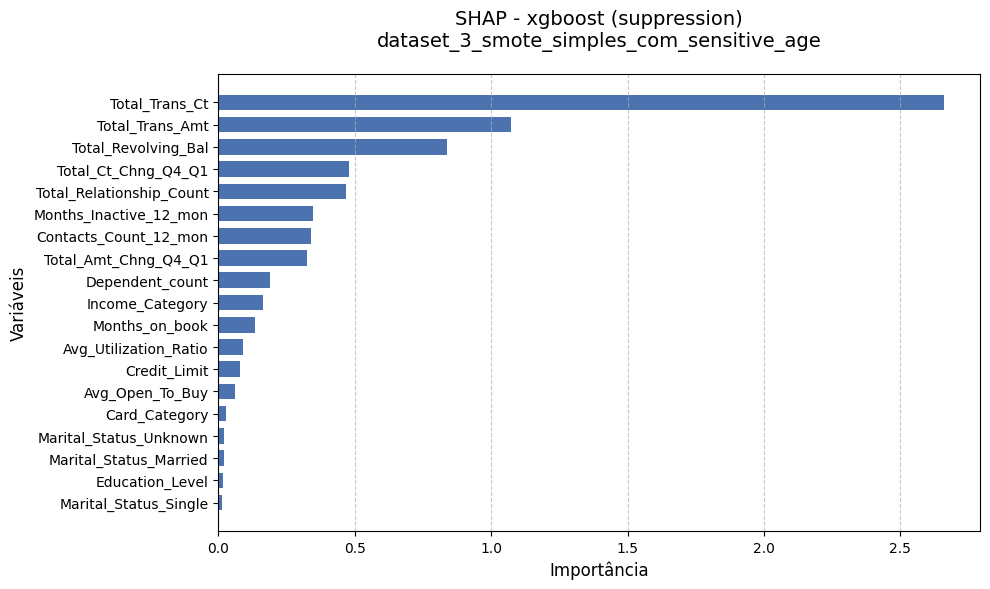

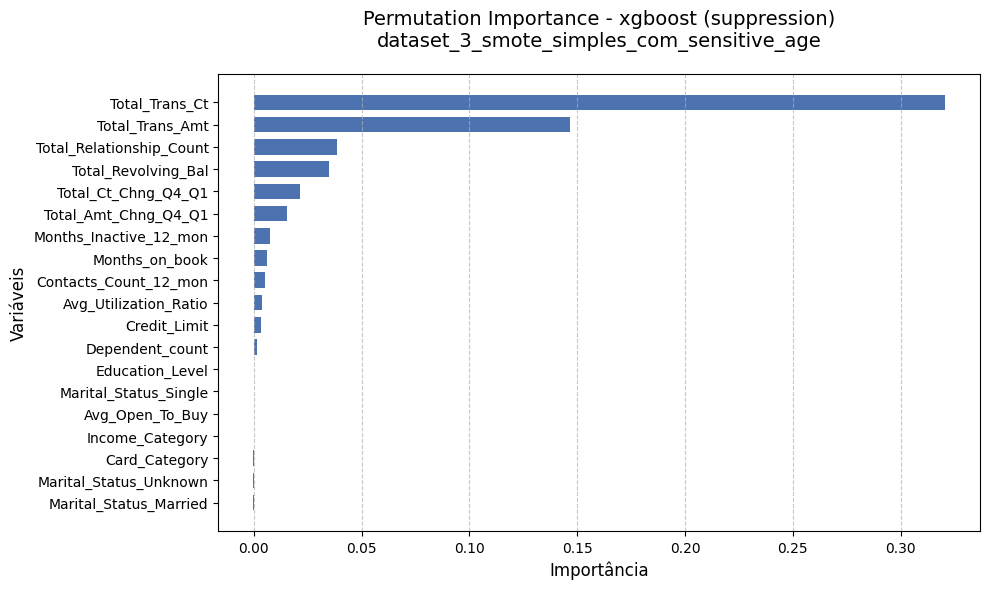

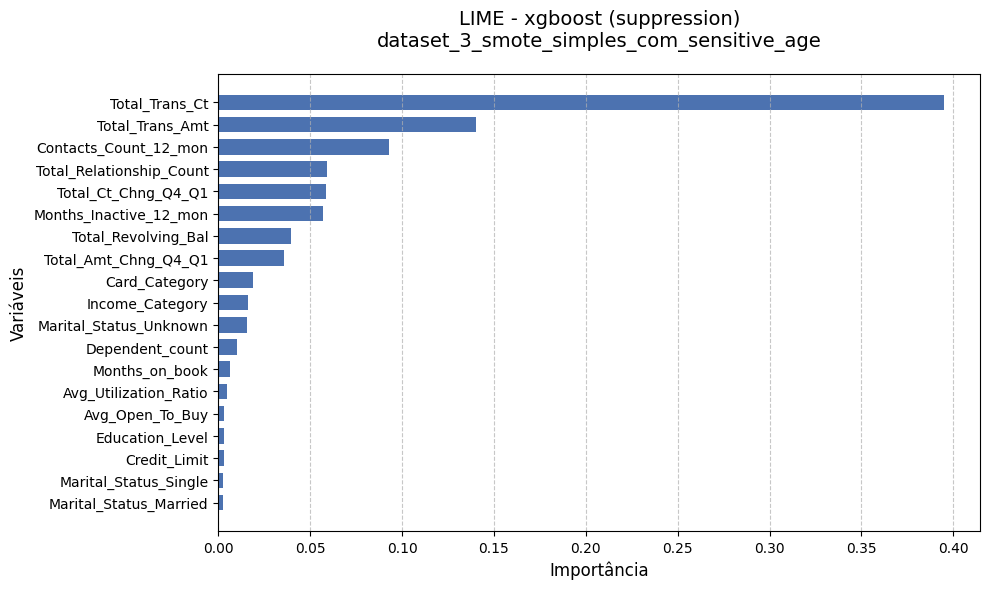


PROCESSANDO: dataset_3_smote_simples_com_sensitive_sexo
MODELO: xgboost | TÉCNICA: synthetic_data_generation
Iniciando cálculo de interpretabilidade específico para: dataset_3_smote_simples_com_sensitive_sexo | xgboost | synthetic_data_generation
  > SHAP concluído em 0.32s
  > Permutation Importance concluída em 2.18s
  > LIME concluído em 67.25s


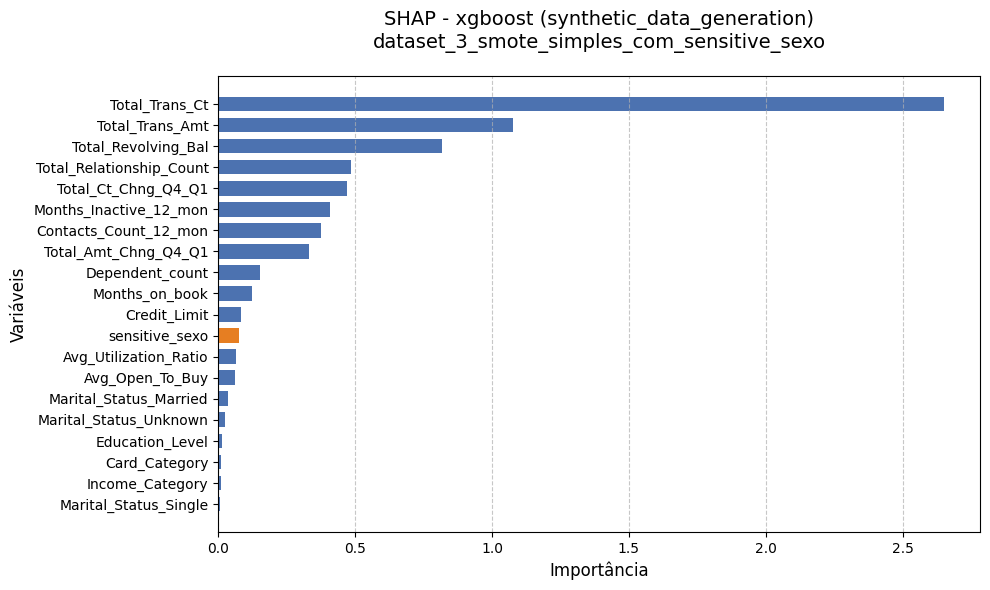

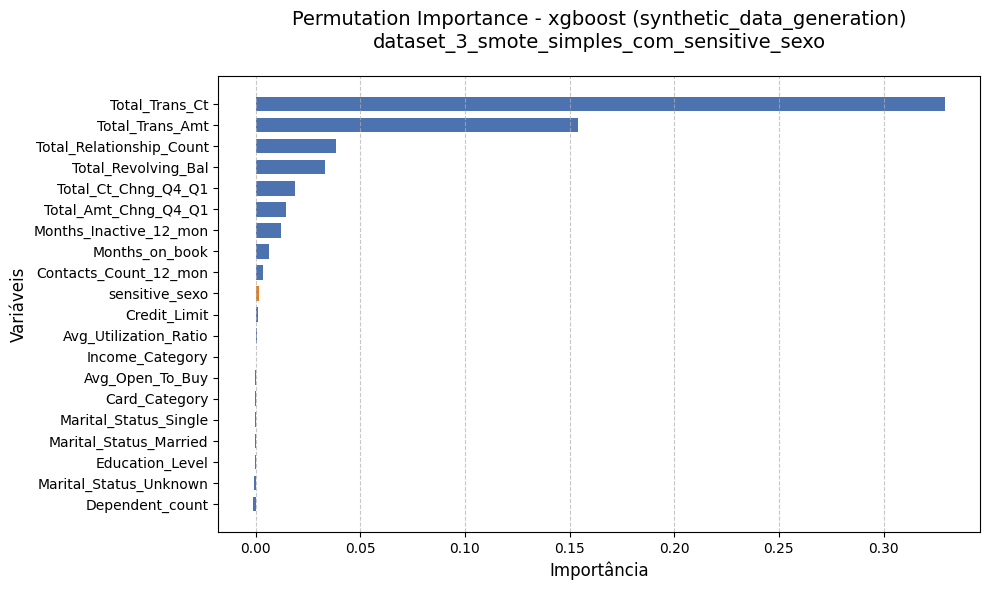

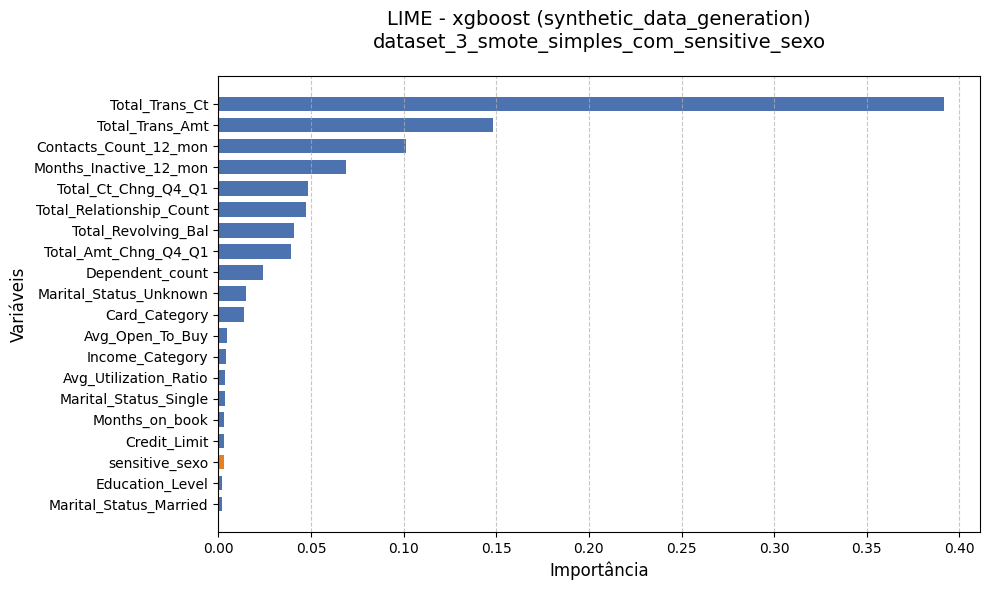


PROCESSANDO: dataset_4_smote_simples_com_sensitive_age
MODELO: regressão_logística | TÉCNICA: disparate_impact_removal
Iniciando cálculo de interpretabilidade específico para: dataset_4_smote_simples_com_sensitive_age | regressão_logística | disparate_impact_removal
  > SHAP concluído em 0.05s
  > Permutation Importance concluída em 3.43s
  > LIME concluído em 56.60s


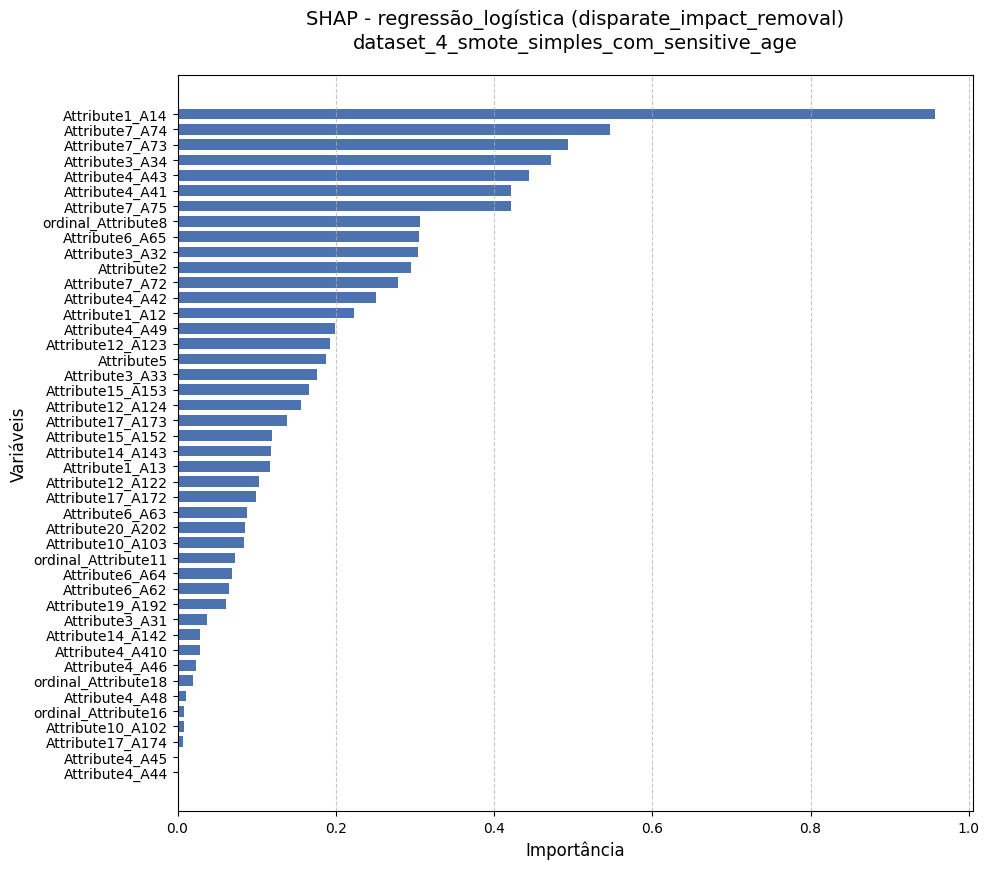

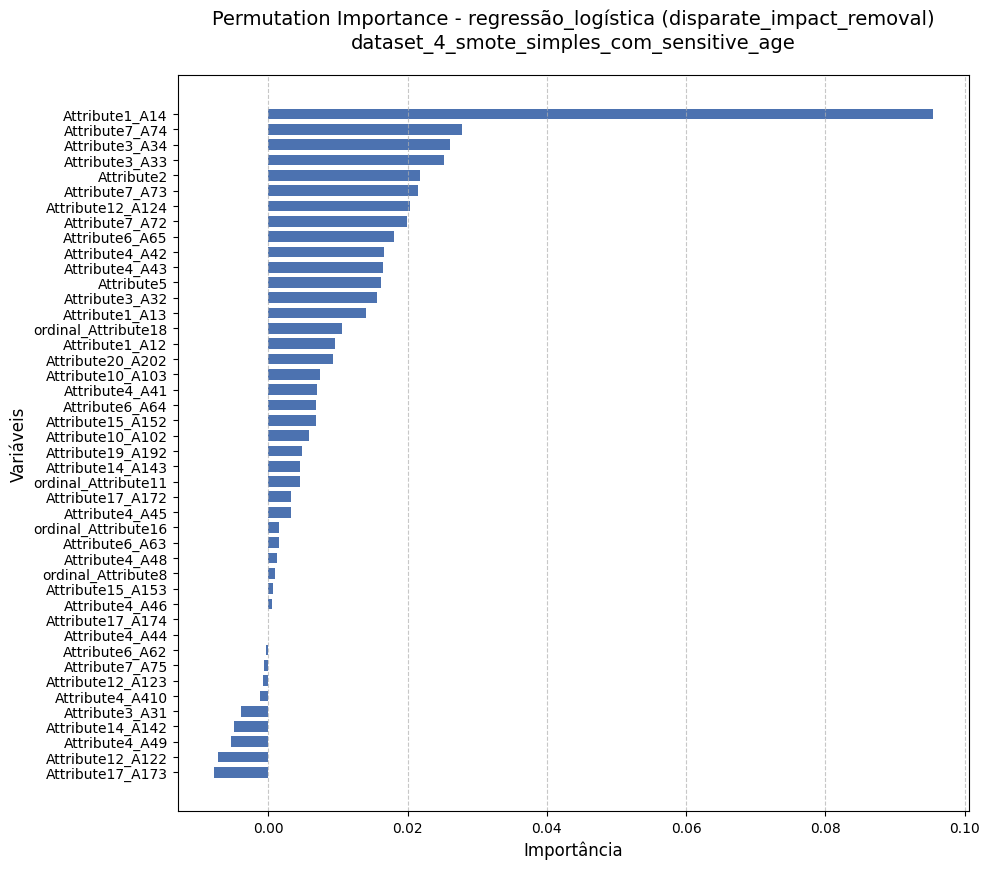

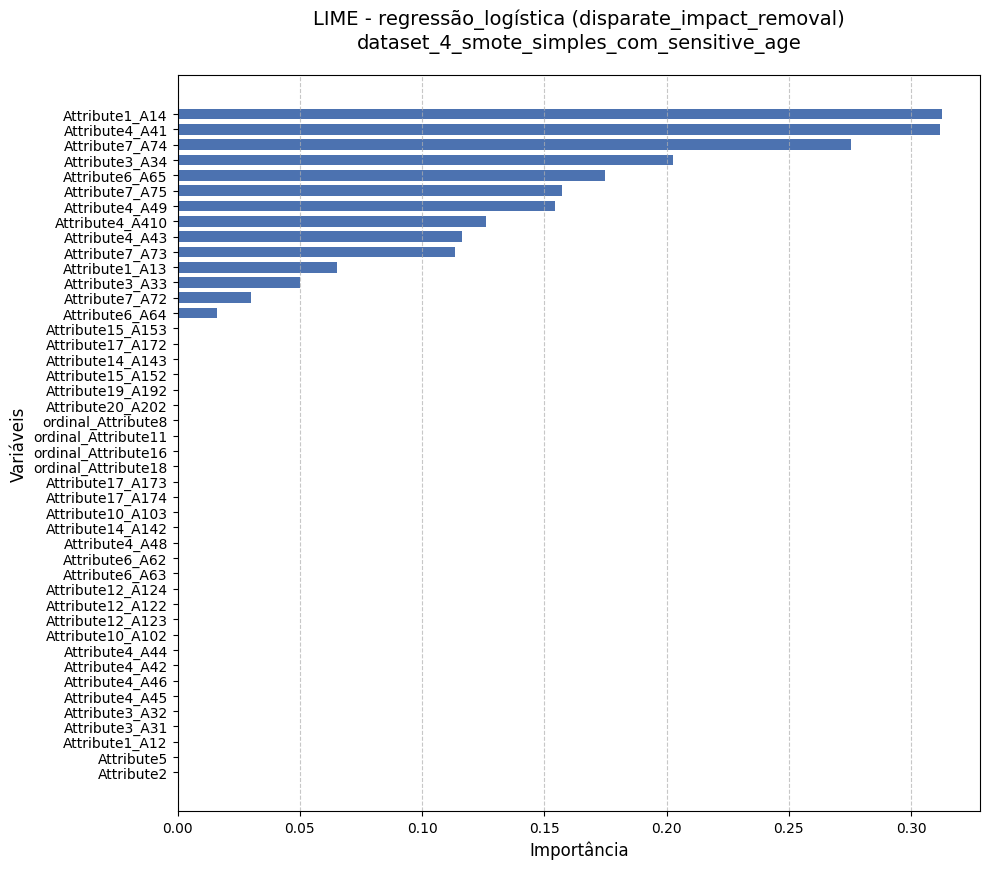


PROCESSANDO: dataset_4_smote_simples_com_sensitive_sexo
MODELO: regressão_logística | TÉCNICA: threshold_optimization
Iniciando cálculo de interpretabilidade específico para: dataset_4_smote_simples_com_sensitive_sexo | regressão_logística | threshold_optimization
  > SHAP concluído em 0.02s
  > Permutation Importance concluída em 3.16s
  > LIME concluído em 58.71s


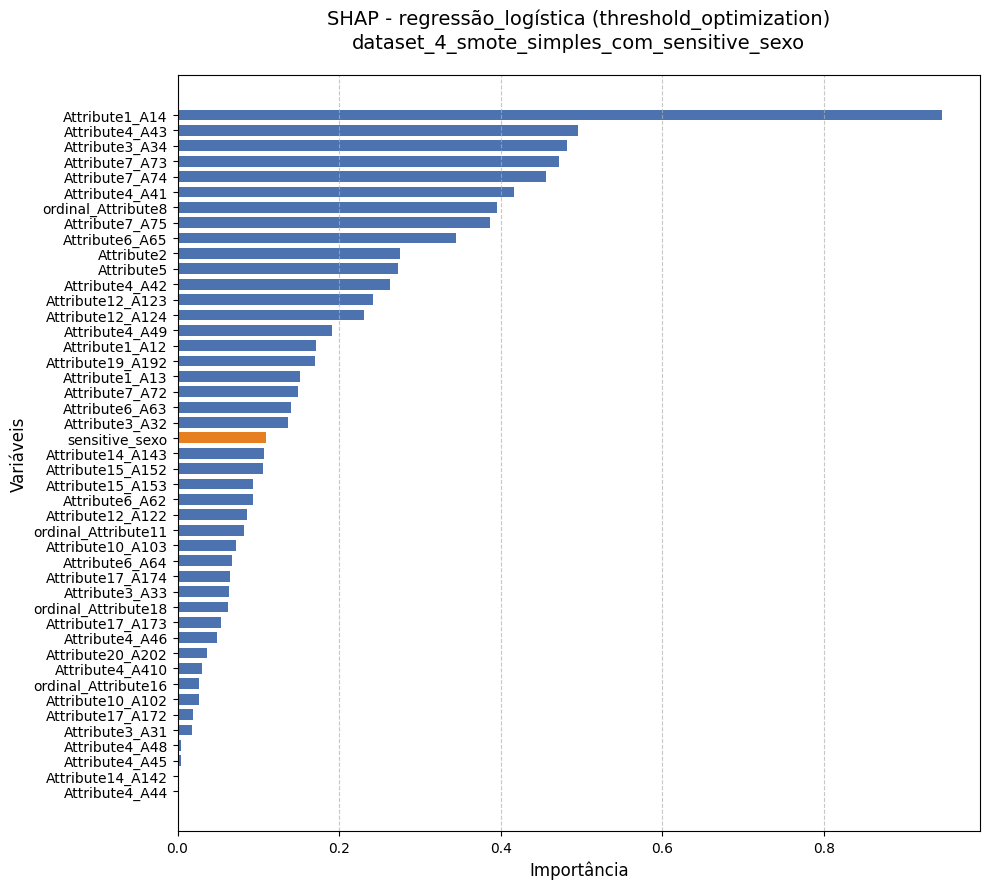

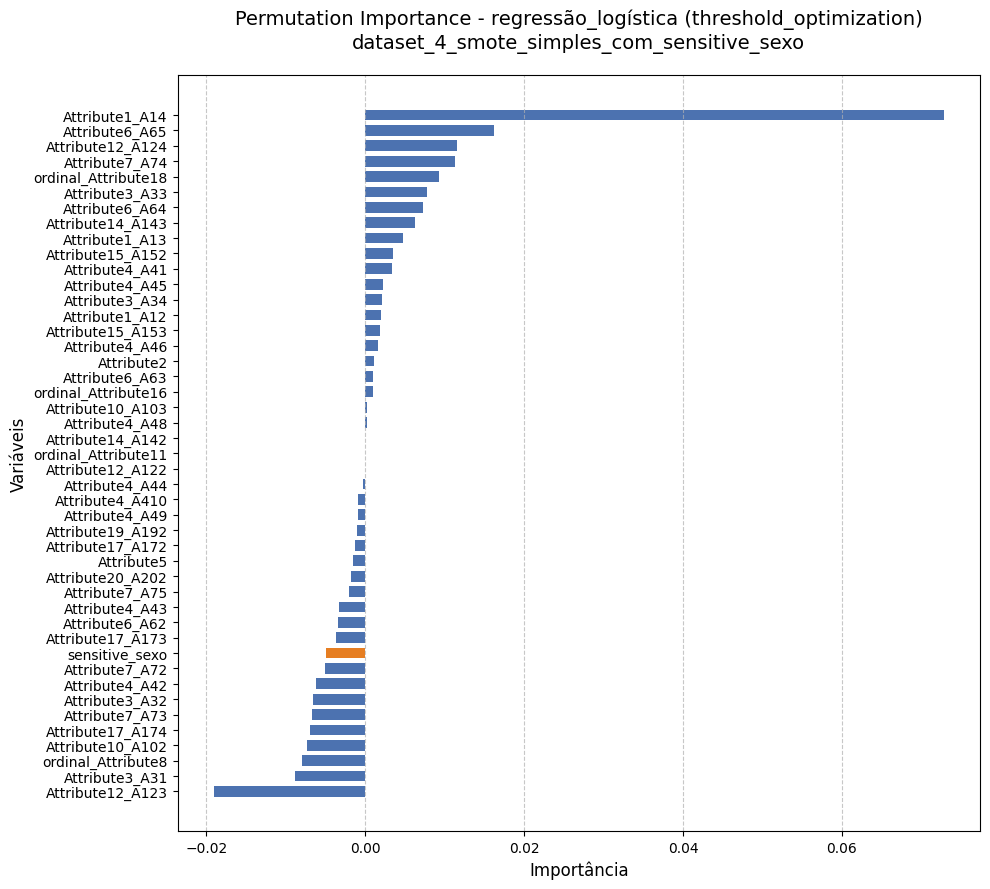

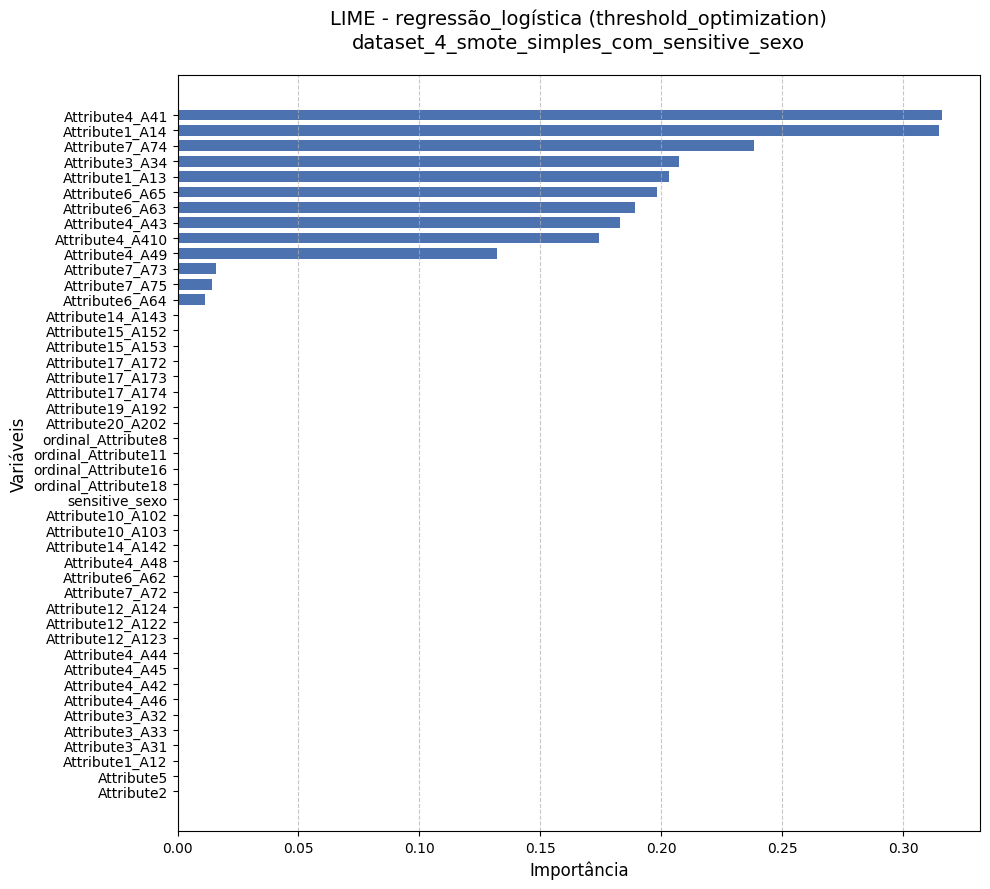

In [29]:
vencedores = [
    # Dataset Original
    {'ds': 'dataset_1_original_com_sensitive_age', 'mo': 'xgboost', 'te': 'threshold_optimization'},
    {'ds': 'dataset_1_original_com_sensitive_sexo', 'mo': 'xgboost', 'te': 'synthetic_data_generation'},
    {'ds': 'dataset_2_original_com_sensitive_age', 'mo': 'regressão_logística', 'te': 'reject_option_classification'},
    {'ds': 'dataset_2_original_com_sensitive_sexo', 'mo': 'xgboost', 'te': 'synthetic_data_generation'},
    {'ds': 'dataset_3_original_com_sensitive_age', 'mo': 'random_forest', 'te': 'calibration'},
    {'ds': 'dataset_3_original_com_sensitive_sexo', 'mo': 'xgboost', 'te': 'sem_tecnica'},
    {'ds': 'dataset_4_original_com_sensitive_age', 'mo': 'xgboost', 'te': 'sem_tecnica'},
    {'ds': 'dataset_4_original_com_sensitive_sexo', 'mo': 'xgboost', 'te': 'sem_tecnica'},
    
    # Algoritmos Vencedores:
      # XGBoost: 6 vezes
      # Random Forest: 1 vez
      # Regressão Logística: 1 vez
    # Técnicas Vencedoras:
      # sem_tecnica: 3 vezes (D3-Sexo, D4-Idade, D4-Sexo)
      # Synthetic Data Generation: 2 vezes (D1-Sexo, D2-Sexo)
      # Threshold Optimization: 1 vez (D1-Idade)
      # Reject Option Classification: 1 vez (D2-Idade)
      # Calibration: 1 vez (D3-Idade)

    # Dataset SMOTE
    {'ds': 'dataset_1_smote_simples_com_sensitive_age', 'mo': 'random_forest', 'te': 'suppression'},
    {'ds': 'dataset_1_smote_simples_com_sensitive_sexo', 'mo': 'random_forest', 'te': 'synthetic_data_generation'},
    {'ds': 'dataset_2_smote_simples_com_sensitive_age', 'mo': 'xgboost', 'te': 'instance_reweighing'},
    {'ds': 'dataset_2_smote_simples_com_sensitive_sexo', 'mo': 'xgboost', 'te': 'instance_reweighing'},
    {'ds': 'dataset_3_smote_simples_com_sensitive_age', 'mo': 'xgboost', 'te': 'suppression'},
    {'ds': 'dataset_3_smote_simples_com_sensitive_sexo', 'mo': 'xgboost', 'te': 'synthetic_data_generation'},
    {'ds': 'dataset_4_smote_simples_com_sensitive_age', 'mo': 'regressão_logística', 'te': 'disparate_impact_removal'},
    {'ds': 'dataset_4_smote_simples_com_sensitive_sexo', 'mo': 'regressão_logística', 'te': 'threshold_optimization'},

    # Algoritmos Vencedores:
      # XGBoost: 4 vezes
      # Random Forest: 2 vezes
      # Regressão Logística: 2 vezes
    # Técnicas Vencedoras:
      # Instance Reweighing: 2 vezes (D2-Idade, D2-Sexo)
      # Suppression: 2 vezes (D1-Idade, D3-Idade)
      # Synthetic Data Generation: 2 vezes (D1-Sexo, D3-Sexo)
      # Disparate Impact Removal: 1 vez (D4-Idade)
      # Threshold Optimization: 1 vez (D4-Sexo)

]

def plotar_importancia(dados_lista, titulo):
    if not dados_lista:
        return
    
    df = pd.DataFrame(dados_lista)
    df = df.sort_values(by='importancia', ascending=True)
    
    altura_dinamica = max(6, len(df) * 0.2) 
    plt.figure(figsize=(10, altura_dinamica))
    
    cores = [
        '#e67e22' if 'sensitive' in str(var).lower() else '#4c72b0' 
        for var in df['variavel']
    ]
    
    barras = plt.barh(df['variavel'], df['importancia'], color=cores, height=0.7)
    
    plt.xlabel('Importância', fontsize=12)
    plt.ylabel('Variáveis', fontsize=12)
    plt.title(titulo, fontsize=14, pad=20)
    
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

historico = {}

for v in vencedores:
    print(f"\n{'='*80}")
    print(f"PROCESSANDO: {v['ds']}")
    print(f"MODELO: {v['mo']} | TÉCNICA: {v['te']}")
    print(f"{'='*80}")
    
    try:
        resultado = gerar_interpretabilidade_especifica(rf, v['ds'], v['mo'], v['te'])
        historico[v['ds']] = resultado

        if resultado['shap']:
            plotar_importancia(resultado['shap'], f"SHAP - {v['mo']} ({v['te']})\n{v['ds']}")
        
        if resultado['permutation']:
            plotar_importancia(resultado['permutation'], f"Permutation Importance - {v['mo']} ({v['te']})\n{v['ds']}")

        if resultado['lime']:
            plotar_importancia(resultado['lime'], f"LIME - {v['mo']} ({v['te']})\n{v['ds']}")

    except Exception as e:
        print(f"Erro ao gerar interpretabilidade para {v['ds']}: {e}")

In [ ]:
# Salvar dicionário de interpretabilidade
joblib.dump(historico, './Resultados/interpretabilidade.joblib')
recuperado = joblib.load('./Resultados/interpretabilidade.joblib')

['./interpretabilidade.joblib']

In [ ]:
# gerar_interpretabilidade(rf, '.')     # Gera a interpretabilidade de todos os testes do dicionário de resultados

In [3]:
# Para visualizar as chaves do dicionário de resultados

def listar_hierarquia_ordenada(dicionario, nivel=0):
    # Ordenar as chaves
    for chave, valor in sorted(dicionario.items()):
        indentacao = "    " * nivel
        print(f"{indentacao}{chave}")
        
        # Acessa os demais dicionários recursivamente
        if isinstance(valor, dict):
            listar_hierarquia_ordenada(valor, nivel + 1)

listar_hierarquia_ordenada(rf)

dataset_1_original_com_sensitive_age
    perceptron
        calibration
            desprivilegiado
                F1_Score
                KS
                ROC_AUC
                matriz_de_confusao
                relatorio_classificacao
                    0
                        f1-score
                        precision
                        recall
                        support
                    1
                        f1-score
                        precision
                        recall
                        support
                    accuracy
                    macro avg
                        f1-score
                        precision
                        recall
                        support
                    weighted avg
                        f1-score
                        precision
                        recall
                        support
            geral
                F1_Score
                KS
                ROC_AUC
               